# Идеи

Взять больше акций и проанализировать группы компаних из одинаковых секторов экономики, чтобы понять, можно ли использовать одну и ту же модель для них

# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from aiomoex import get_board_candles
import asyncio
import aiohttp
from statsmodels.graphics.tsaplots import plot_acf

## 1.2 Функции

In [5]:
VALID_INTERVALS = {
    1: "1 минута",
    10: "10 минут", 
    60: "1 час",
    24: "1 день",
    7: "1 неделя",
    31: "1 месяц"
}

In [146]:
def plot_normalized_volatility_grid(stock_data, window=20, figsize=(14, 5)):
    """
    Визуализация нормализованной волатильности для каждой акции.
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными акций
    window : int
        Окно для расчета втокорреляции (дни)
    figsize : tuple
        Размер графика (ширина, высота КАЖДОГО subplot)
    """
    
    n_tickers = len(stock_data)
    n_cols = 2
    n_rows = (n_tickers + 1) // 2
    
    total_width = figsize[0]
    total_height = figsize[1] * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(total_width, total_height))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    avg_volatilities = {}
    
    for idx, (ticker, df) in enumerate(stock_data.items()):
        if df.empty:
            continue
            
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        df_sorted = df.sort_values('begin')
        
        returns = df_sorted['close'].pct_change()
        
        volatility = returns.rolling(window=window).std() * np.sqrt(252)
        
        normalized_vol = (volatility - volatility.min()) / (volatility.max() - volatility.min())
        
        avg_vol = volatility.mean()
        avg_volatilities[ticker] = avg_vol
        
        ax.plot(df_sorted['begin'], normalized_vol, 
                linewidth=2, 
                color='#2E86AB',
                alpha=0.8)
        
        ax.set_title(f'{ticker}\nСр. волатильность: {avg_vol:.1%}', fontsize=12)
        ax.set_xlabel('Дата')
        ax.set_ylabel('Норм. волатильность')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    for idx in range(n_tickers, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("Средняя годовая волатильность по акциям:")
    print("-" * 40)
    for ticker, vol in sorted(avg_volatilities.items(), key=lambda x: x[1], reverse=True):
        print(f"{ticker}: {vol:.1%}")
    
    print(f"\nМаксимальная: {max(avg_volatilities.values()):.1%}")
    print(f"Минимальная: {min(avg_volatilities.values()):.1%}")
    print(f"Средняя: {np.mean(list(avg_volatilities.values())):.1%}")

In [84]:
def plot_autocorrelation_periods(stock_data, n_periods=3, lags=50, figsize=(12, 5)):
    """
    Визуализация автокорреляции цен закрытия по временным периодам.
    
    Разбивает данные каждого тикера на равные периоды и строит графики
    автокорреляционной функции для анализа изменения поведения акций во времени.
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными, где ключи - тикеры, значения - DataFrame с колонками:
        'begin' (дата) и 'close' (цена закрытия)
    n_periods : int, default=3
        Количество периодов для разбиения данных
    lags : int, default=50
        Количество лагов для анализа автокорреляции
    figsize : tuple, default=(15, 5)
        Размер фигуры для каждого тикера
    """
    
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10
    })
    
    for ticker, df in stock_data.items():
        if df.empty:
            continue
            
        df_sorted = df.sort_values('begin')
        total_days = len(df_sorted)
        period_size = total_days // n_periods
        
        fig, axes = plt.subplots(1, n_periods, figsize=(figsize[0], figsize[1]))
        
        if n_periods == 1:
            axes = [axes]
        
        for period in range(n_periods):
            start_idx = period * period_size
            end_idx = (period + 1) * period_size if period < n_periods - 1 else total_days
            
            period_data = df_sorted.iloc[start_idx:end_idx]
            close_prices = period_data['close']
            
            start_date = period_data['begin'].iloc[0].strftime('%Y-%m-%d')
            end_date = period_data['begin'].iloc[-1].strftime('%Y-%m-%d')
            
            plot_acf(close_prices, ax=axes[period], lags=lags, alpha=0.05)
            
            axes[period].set_title(f'{ticker} - Период {period+1}\n{start_date} - {end_date}', 
                                 fontsize=14, pad=20)
            axes[period].set_xlabel('Лаг', fontsize=12)
            axes[period].set_ylabel('Автокорреляция', fontsize=12)
            axes[period].grid(True, alpha=0.3)
            
            axes[period].tick_params(axis='both', which='major', labelsize=10)
        
        plt.tight_layout()
        plt.show()

In [7]:
async def fetch_ticker_data(session: aiohttp.ClientSession, ticker: str, interval: int, start_date: str, end_date: str) -> dict[str, pd.DataFrame]:
    try:
        res = await get_board_candles(session, ticker, interval, start_date, end_date)
        if res:
            df = pd.DataFrame(res)
            
            if 'end' in df.columns:
                df = df.drop('end', axis=1)
            
            df['begin'] = pd.to_datetime(df['begin'])
            
            if interval in [24, 7, 31]:
                df['begin'] = df['begin'].dt.normalize()

            if 'begin' in df.columns:
                cols = ['begin'] + [col for col in df.columns if col != 'begin']
                df = df[cols]
            
            df['ticker'] = ticker
            return {ticker: df}
        else:
            return {ticker: pd.DataFrame()}
    except Exception as e:
        print(f'Ошибка парсинга. Не удалось получить данные для {ticker}, {e}')
        return {ticker: pd.DataFrame()}

async def get_moex_data(tickers: list[str], start_date: str, end_date: str, interval: int = 24) -> dict[str, pd.DataFrame]:
    if interval not in VALID_INTERVALS:
        raise ValueError(f"Неверный интервал. Допустимые значения: {list(VALID_INTERVALS.keys())}")
    
    async with aiohttp.ClientSession() as session:
        coros = [fetch_ticker_data(session, ticker, interval, start_date, end_date) for ticker in tickers]
        stock_data = await asyncio.gather(*coros)
    
    stock_data_dict = {k: v for d in stock_data for k, v in d.items()}
    return stock_data_dict

In [8]:
def plot_enhanced_ticker_charts(stock_data, figsize=(16, 8)):
    """
    Строит расширенные графики для каждого тикера с дополнительной информацией
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными
    figsize : tuple
        Размер каждого графика
    """
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3F7CAC']
    
    for i, (ticker, df) in enumerate(stock_data.items()):
        if df.empty:
            continue
            
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
        
        df = df.sort_values('begin')
        
        color = colors[i % len(colors)]
        ax1.plot(df['begin'], df['close'], 
                linewidth=2.5, 
                color=color,
                label='Цена закрытия')
        
        ax1.set_title(f'Акции {ticker} - Анализ цен', fontsize=16, fontweight='bold', pad=20)
        ax1.set_ylabel('Цена (руб)', fontsize=12)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.bar(df['begin'], df['volume'], 
               color=color, 
               alpha=0.6,
               label='Объем торгов')
        
        ax2.set_xlabel('Дата', fontsize=12)
        ax2.set_ylabel('Объем', fontsize=12)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

# 2 Парсинг данных

## 2.1 Данные по "Голубым фишкам" за последние 5 лет

In [15]:
tickers = ['SBER', 'GAZP', 'LKOH', 'ROSN', 'YDEX', 'VTBR', 'TATN', 'GMKN']
stock_data = await get_moex_data(
    tickers,
    start_date='2020-10-01', 
    end_date='2025-10-01', 
    interval=24
)

## 2.2 Данные по "Голубым фишкам" в период ферваля 2022 года

In [17]:
tickers = ['SBER', 'GAZP', 'LKOH', 'ROSN', 'YDEX', 'VTBR', 'TATN', 'GMKN']
stock_data_2022 = await get_moex_data(
    tickers,
    start_date='2022-02-01', 
    end_date='2022-04-01', 
    interval=24
)

## 2.3 Данные по "Голубым фишкам" c 2022-05-01

In [21]:
tickers = ['SBER', 'GAZP', 'LKOH', 'ROSN', 'YDEX', 'VTBR', 'TATN', 'GMKN']
stock_data_final = await get_moex_data(
    tickers,
    start_date='2022-05-01', 
    end_date='2025-10-01', 
    interval=24
)

# 3 Анализ 

## 3.1 Первичный анализ

### 3.1.1 Структура данных

Общая информация

| Параметр | Значение |
|----------|----------|
| **Период измерений** | 2020-10-01 - 2025-10-01 |
| **Периодичность** | Дневные данные |
| **Тип данных** | Временные ряды финансовых показателей |

Основные признаки

1. Временные метки
- **`begin`** - Дата и время начала торгового периода

2. Ценовые характеристики
- **`open`** - Цена открытия торгового периода
- **`close`** - Цена закрытия торгового периода  
- **`high`** - Максимальная цена за период
- **`low`** - Минимальная цена за период

3. Объемные показатели
- **`volume`** - Объем торгов в штуках акций
- **`value`** - Объем торгов в денежном выражении (рубли)

4. Идентификаторы
- **`ticker`** - Идентификатор ценной бумаги (например, SBER)

Типы данных

| Признак | Тип данных | Описание |
|---------|------------|----------|
| `begin` | DateTime | Временная метка |
| `open`, `close`, `high`, `low`, `value` | Float64 | Финансовые показатели |
| `volume` | Int64 | Количество акций |
| `ticker` | String | Идентификатор эмитента |

In [72]:
stock_data['SBER'].head()

,begin,open,close,high,low,value,volume,ticker
0,2020-10-01,229.08,227.23,229.90,226.86,1.779106e+10,77828210,SBER
1,2020-10-02,210.40,208.80,211.39,206.50,2.383885e+10,114322450,SBER
2,2020-10-05,209.65,208.89,210.69,207.72,9.513875e+09,45601880,SBER
3,2020-10-06,209.00,211.18,212.99,208.35,1.849484e+10,87529560,SBER
4,2020-10-07,211.30,210.60,212.66,209.03,1.305911e+10,62052620,SBER


### 3.1.2 Анализ пропусков 

In [96]:
for ticker in tickers:
    print(f"В данных {ticker} {stock_data[ticker].isna().sum().sum()} прокусков")

В данных SBER 0 прокусков
В данных GAZP 0 прокусков
В данных LKOH 0 прокусков
В данных ROSN 0 прокусков
В данных YDEX 0 прокусков
В данных VTBR 0 прокусков
В данных TATN 0 прокусков
В данных GMKN 0 прокусков


### 3.1.3 Типы данных и описательные статистики

In [74]:
stock_data['SBER'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1299 entries, 0 to 1298
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   begin   1299 non-null   datetime64[ns]
 1   open    1299 non-null   float64       
 2   close   1299 non-null   float64       
 3   high    1299 non-null   float64       
 4   low     1299 non-null   float64       
 5   value   1299 non-null   float64       
 6   volume  1299 non-null   int64         
 7   ticker  1299 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 81.3+ KB


In [84]:
stock_data['SBER'][['open', 'close', 'high', 'low', 'value', 'volume', 'ticker']].describe()

,open,close,high,low,value,volume
count,1299.000000,1299.000000,1299.000000,1299.000000,1.299000e+03,1.299000e+03
mean,255.904627,255.838553,258.619384,252.806982,1.365167e+10,5.633317e+07
std,66.686178,66.650157,66.747202,66.596594,1.403666e+10,6.336035e+07
min,96.550000,101.500000,106.770000,89.590000,1.329026e+08,4.160400e+05
25%,232.785000,233.835000,236.435000,229.395000,6.818918e+09,2.833540e+07
50%,274.700000,274.490000,276.660000,271.800000,1.045517e+10,4.337664e+07
75%,306.780000,306.975000,308.875000,303.870000,1.625135e+10,6.639974e+07
max,385.880000,387.600000,388.110000,376.720000,2.385837e+11,1.084508e+09


## 3.2 Визуализация цен

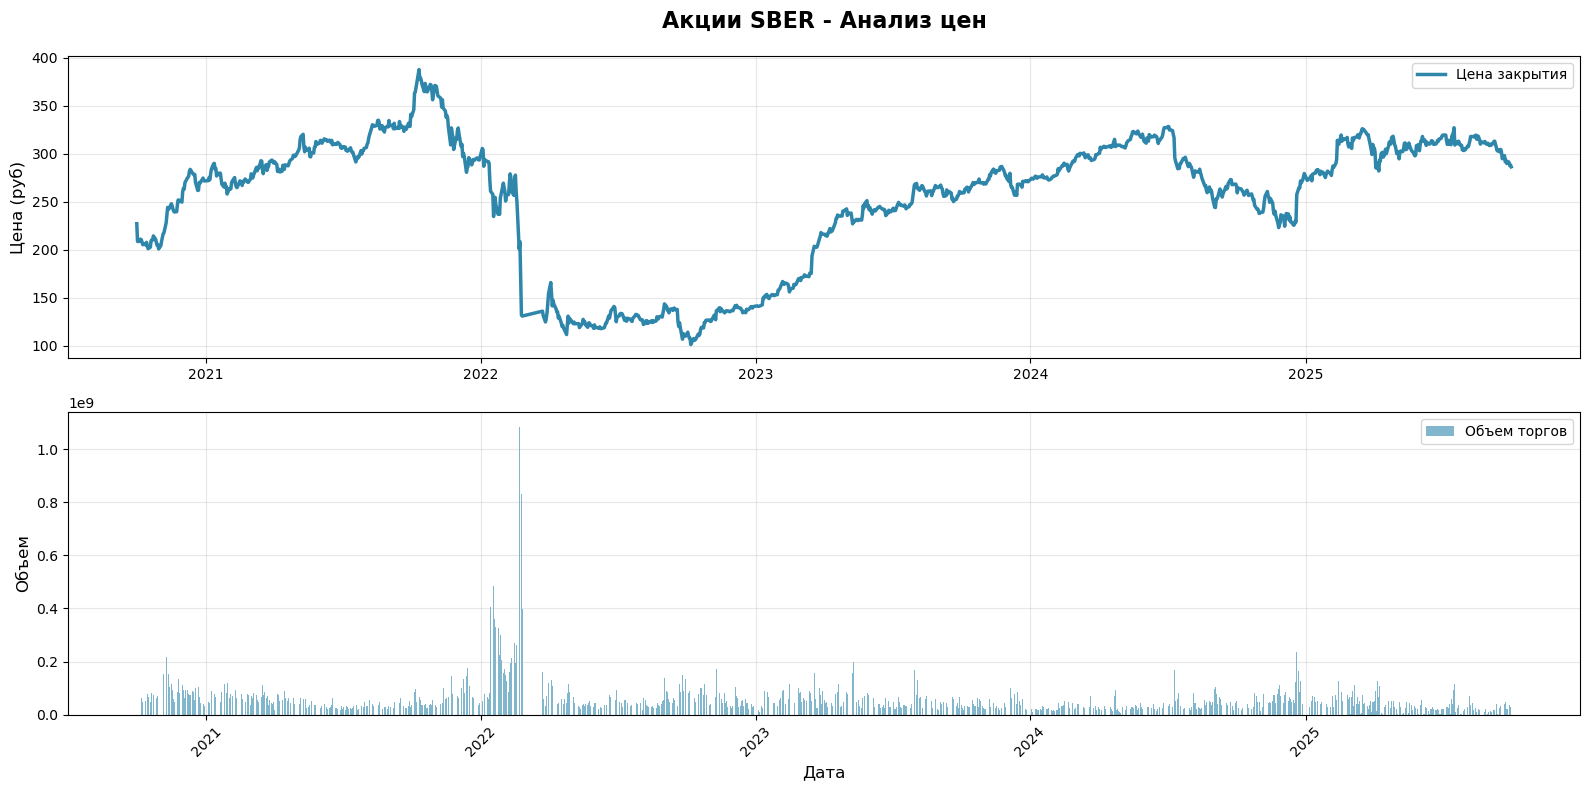

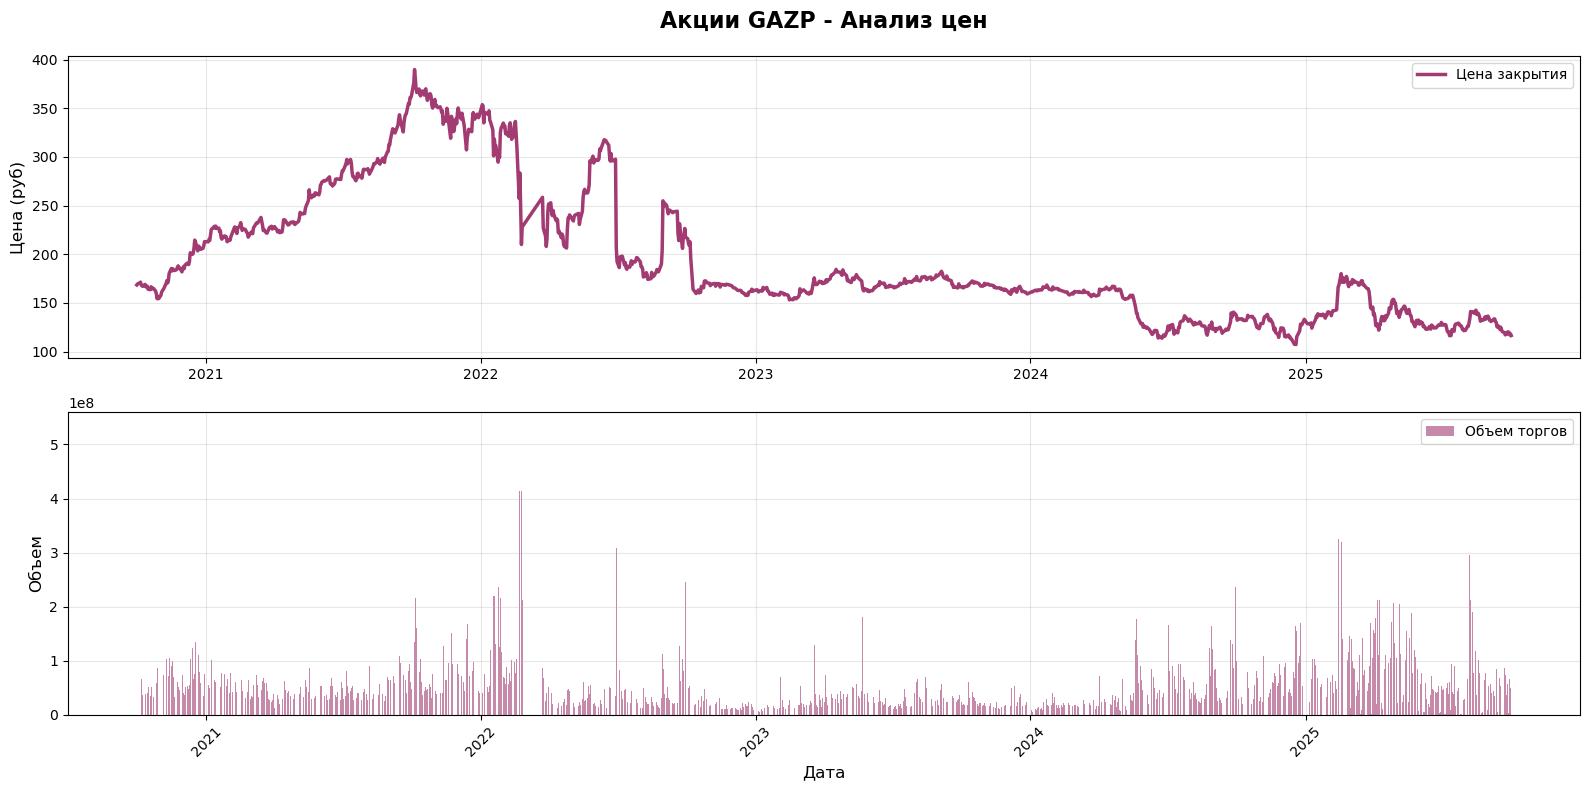

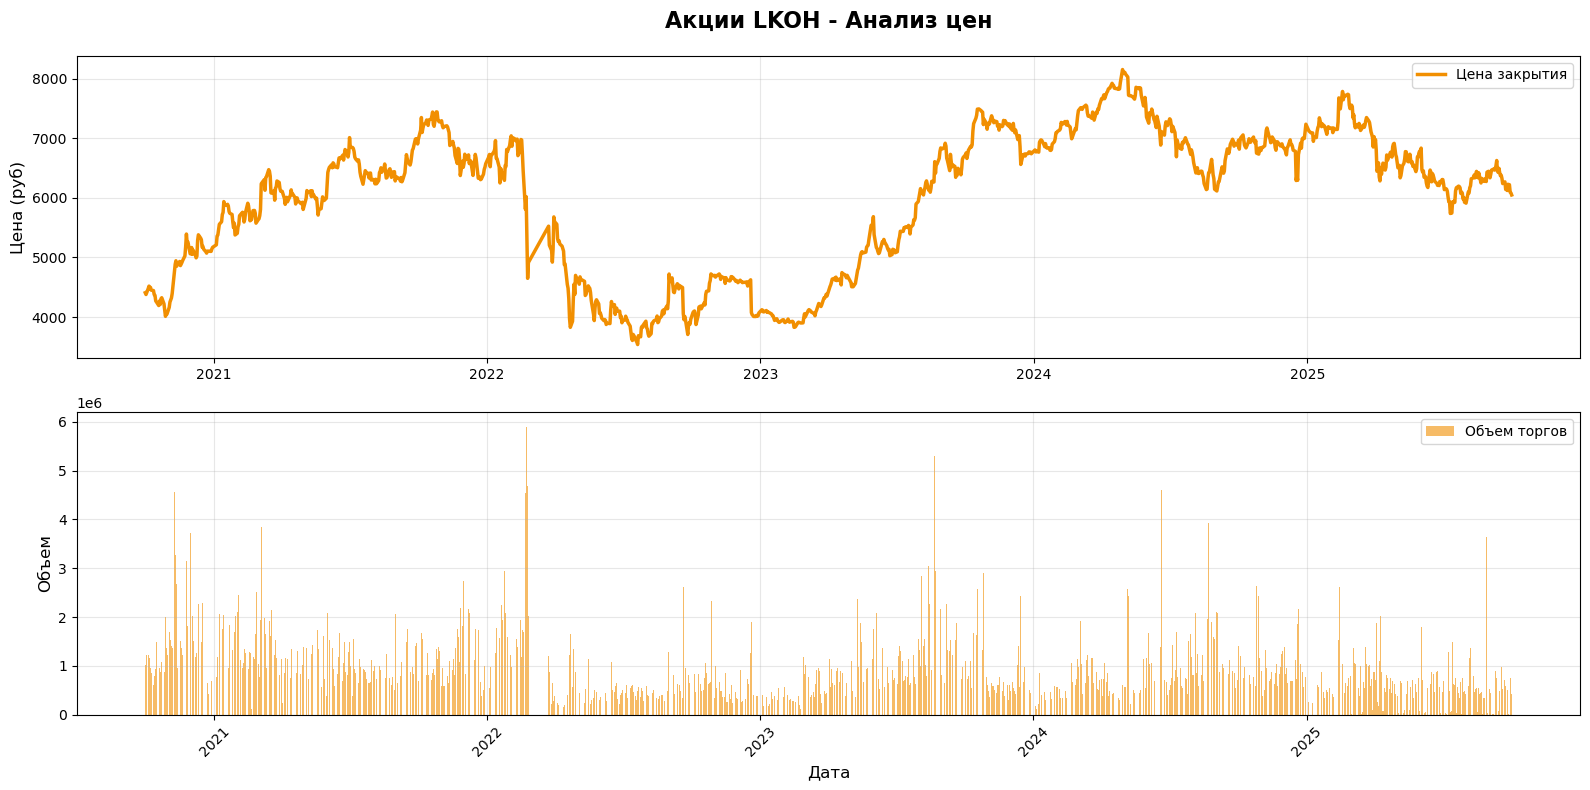

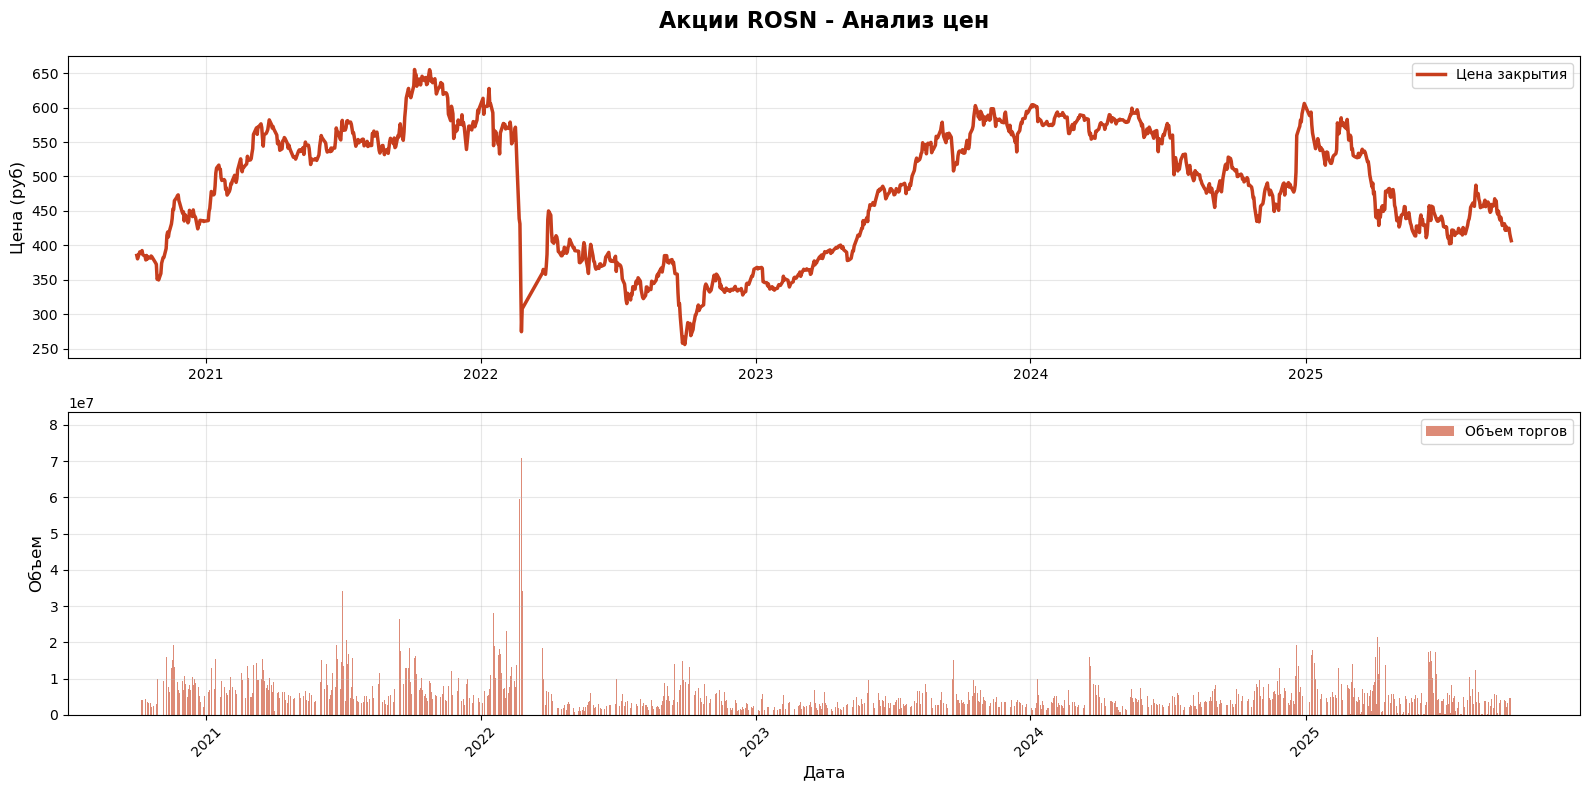

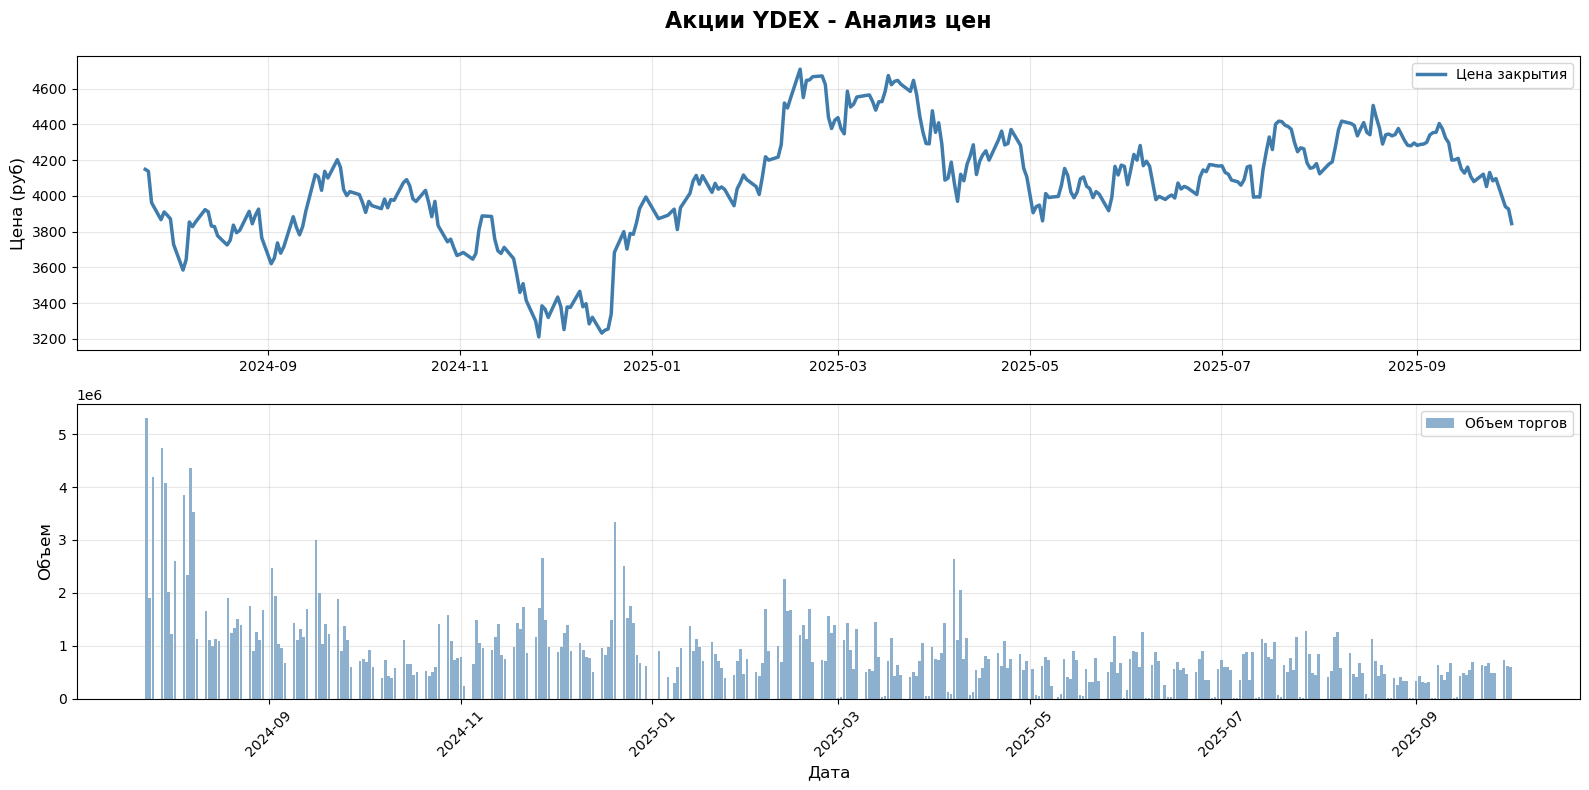

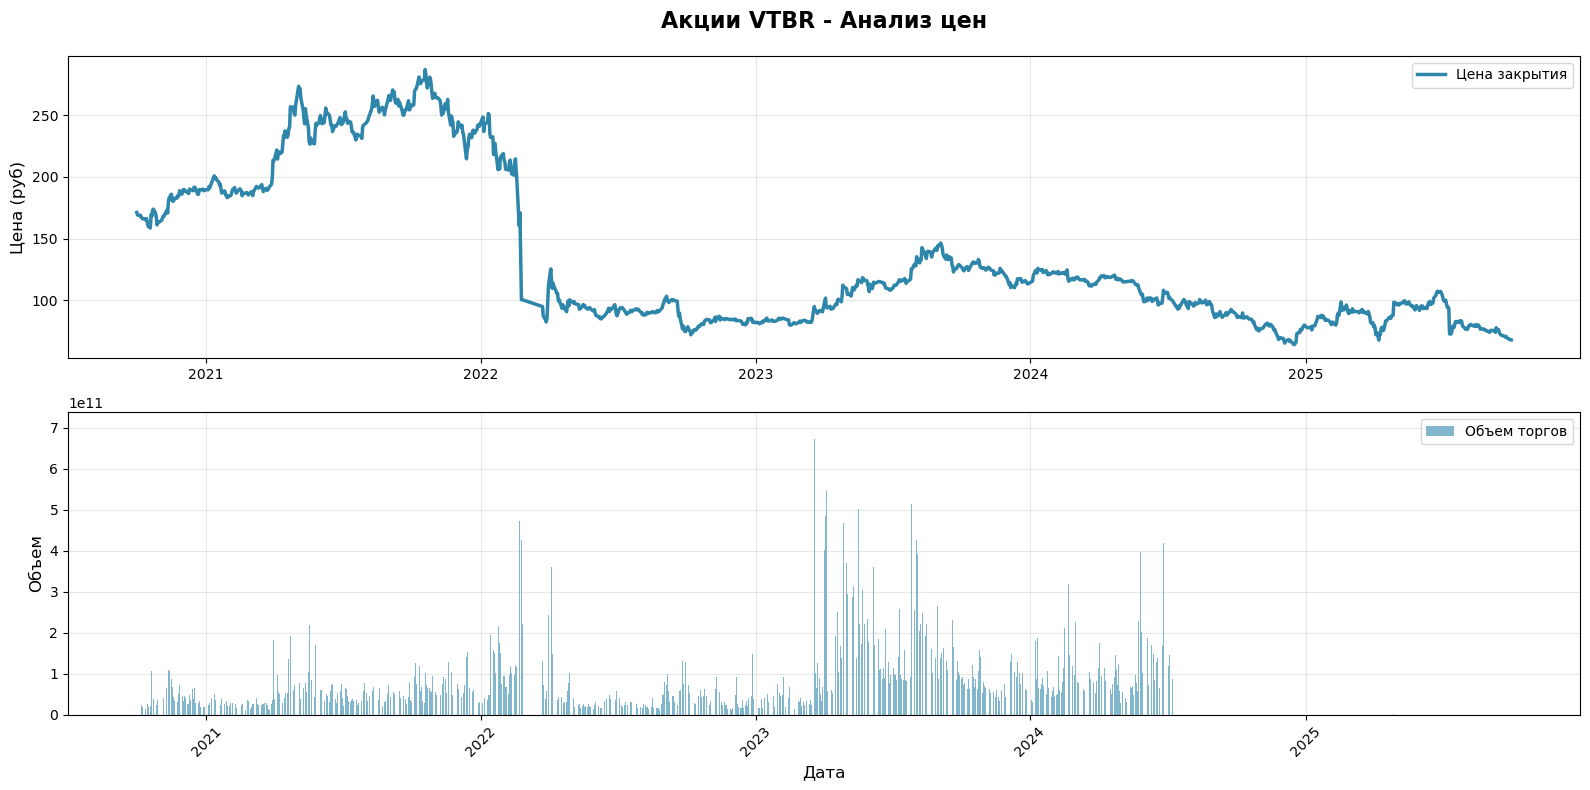

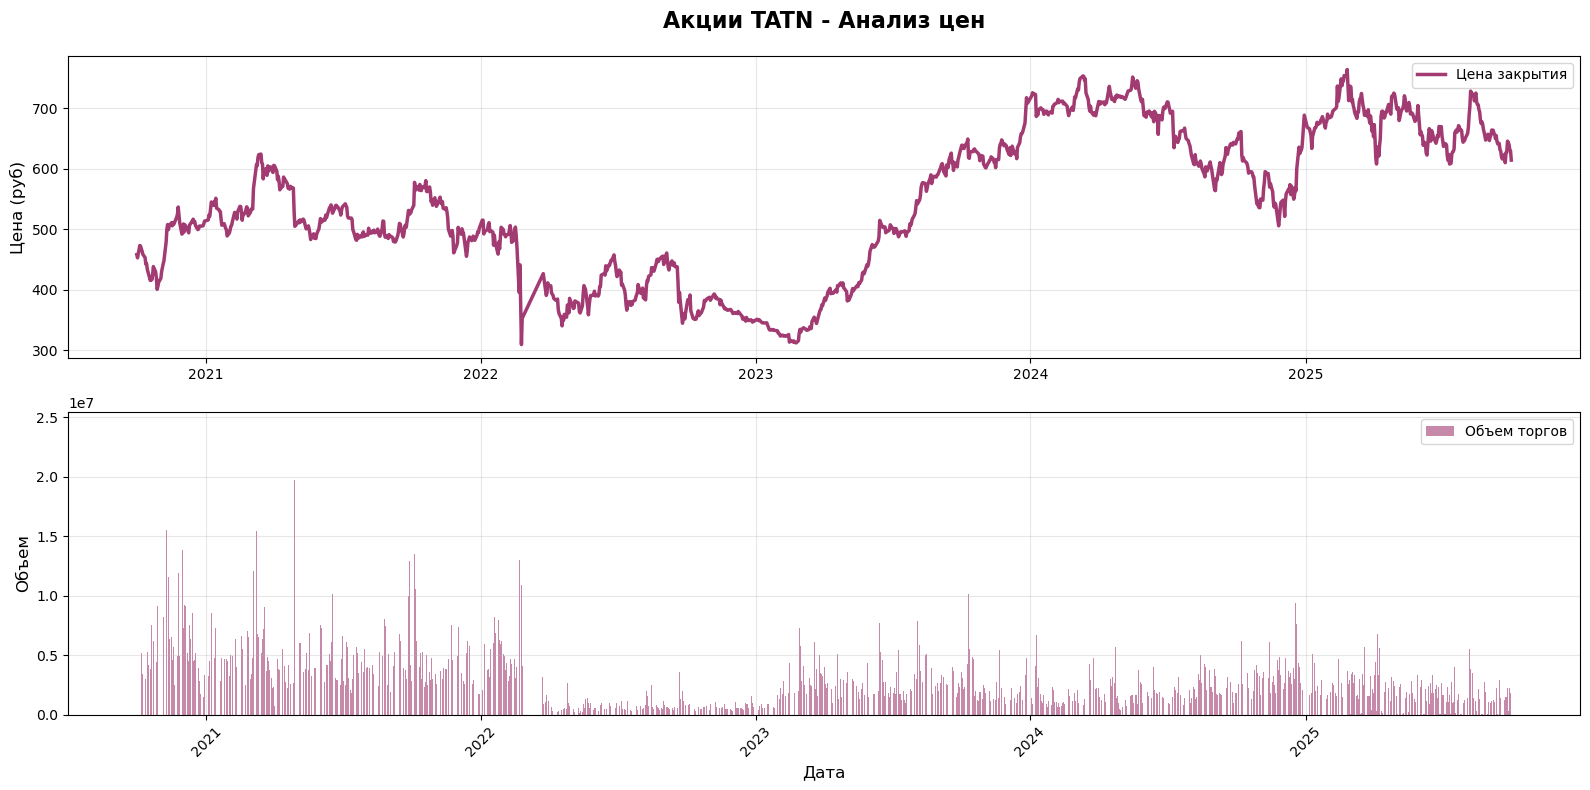

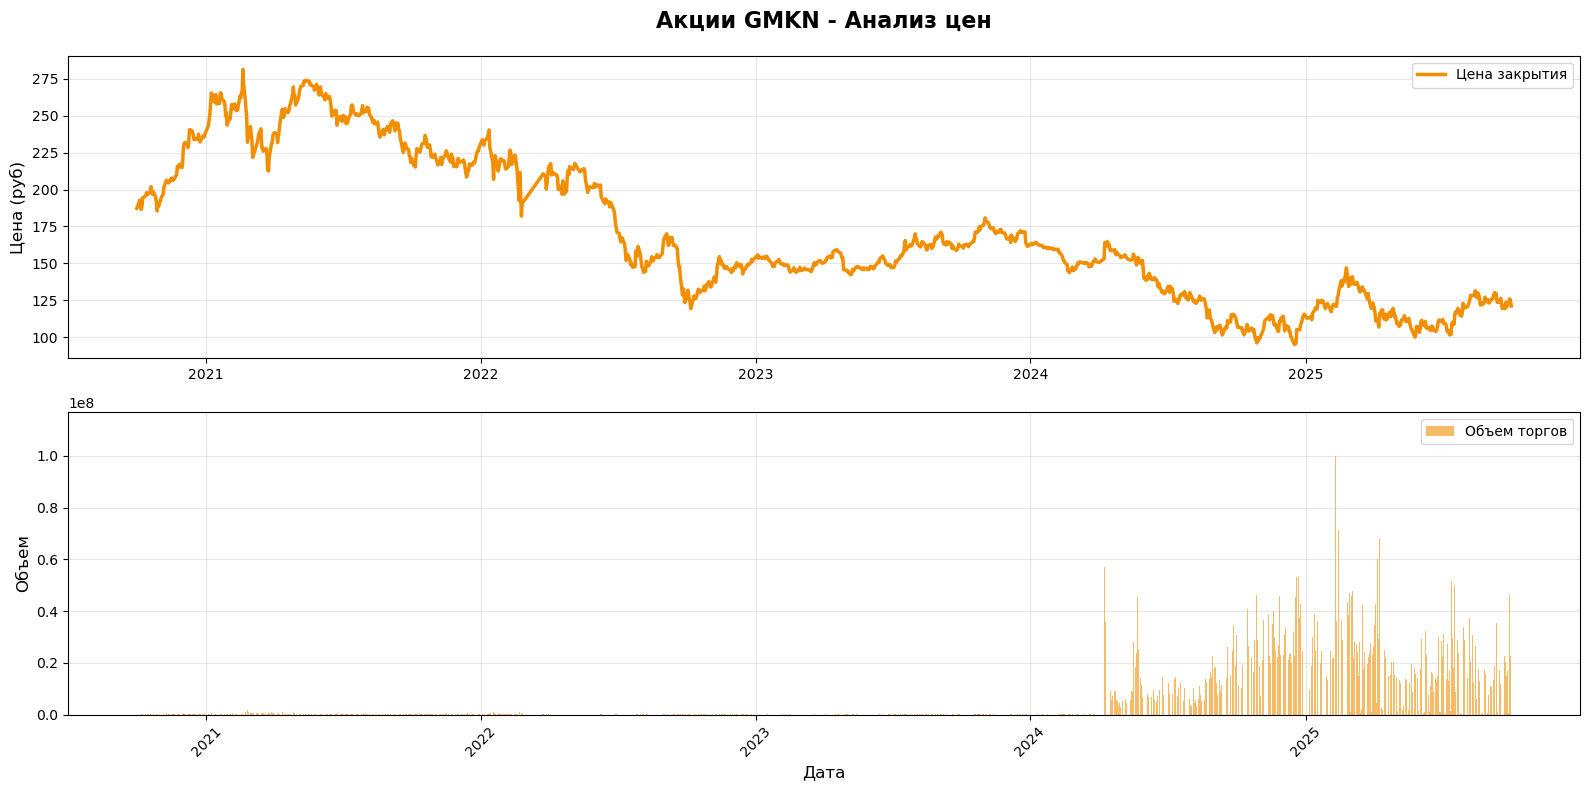

In [112]:
plot_enhanced_ticker_charts(stock_data)

## Вывод

По графикам видно, что в феврале 2022 года по всем акциям идет сильная просадка, за которой следует период отсутствия торгов

## 3.3 Анализ цен закрытия и сравнение с реальными

In [144]:
stock_data['LKOH'][stock_data['LKOH']['begin'] == '2024-04-30']

,begin,open,close,high,low,value,volume,ticker
890,2024-04-30,8152.5,8085.5,8175.0,8080.0,3.532835e+09,435472,LKOH


In [148]:
print(stock_data['YDEX'].iloc[stock_data['YDEX']['close'].argmax()])
print()
print(stock_data['YDEX'].iloc[stock_data['YDEX']['close'].argmin()])

begin     2025-02-17 00:00:00
open                   4590.5
close                  4709.0
high                   4718.0
low                    4585.0
value            5644075547.5
volume                1210212
ticker                   YDEX
Name: 145, dtype: object

begin     2024-11-26 00:00:00
open                   3306.0
close                  3211.0
high                   3354.5
low                    3171.0
value            5551179194.5
volume                1708968
ticker                   YDEX
Name: 89, dtype: object


По данным сайта TradingView, самая высокая цена акций Сбербанка (SBER) за всё время была достигнута 11 октября 2021 года и составила 388,11 рубля.

In [135]:
print(stock_data['SBER'].iloc[stock_data['SBER']['close'].argmax()])
print()
print(stock_data['SBER'].iloc[stock_data['SBER']['close'].argmin()])

begin     2021-10-11 00:00:00
open                    375.0
close                   387.6
high                   388.11
low                     375.0
value      25575373781.299999
volume               66699560
ticker                   SBER
Name: 261, dtype: object

begin     2022-10-07 00:00:00
open                    107.7
close                   101.5
high                   108.48
low                     101.3
value            9560941533.5
volume               90989490
ticker                   SBER
Name: 493, dtype: object


## 3.4 Анализ котировок в близи даты 2022-02-24

### 3.4.1 Визуализация

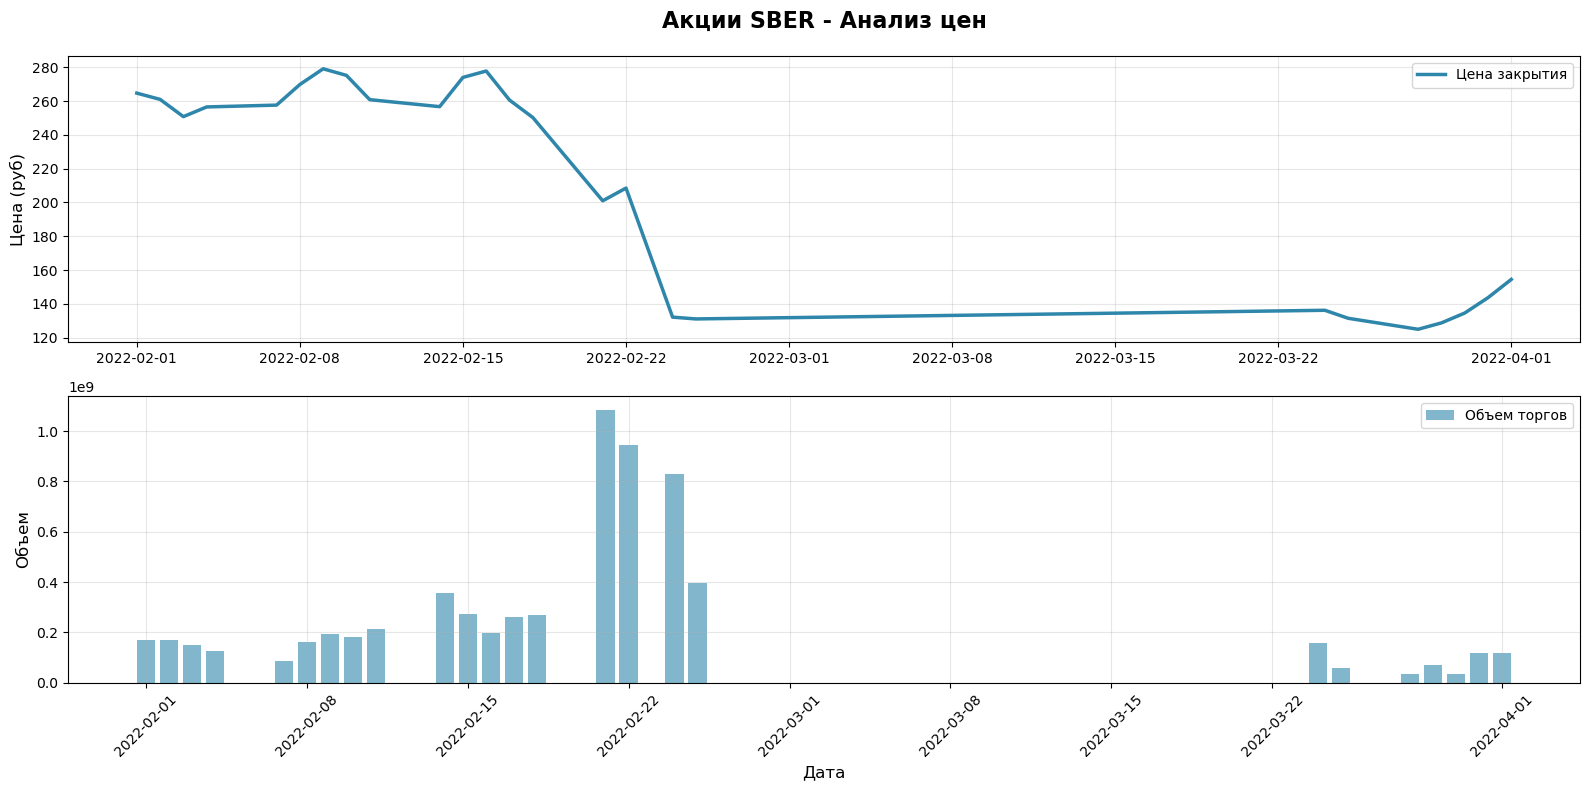

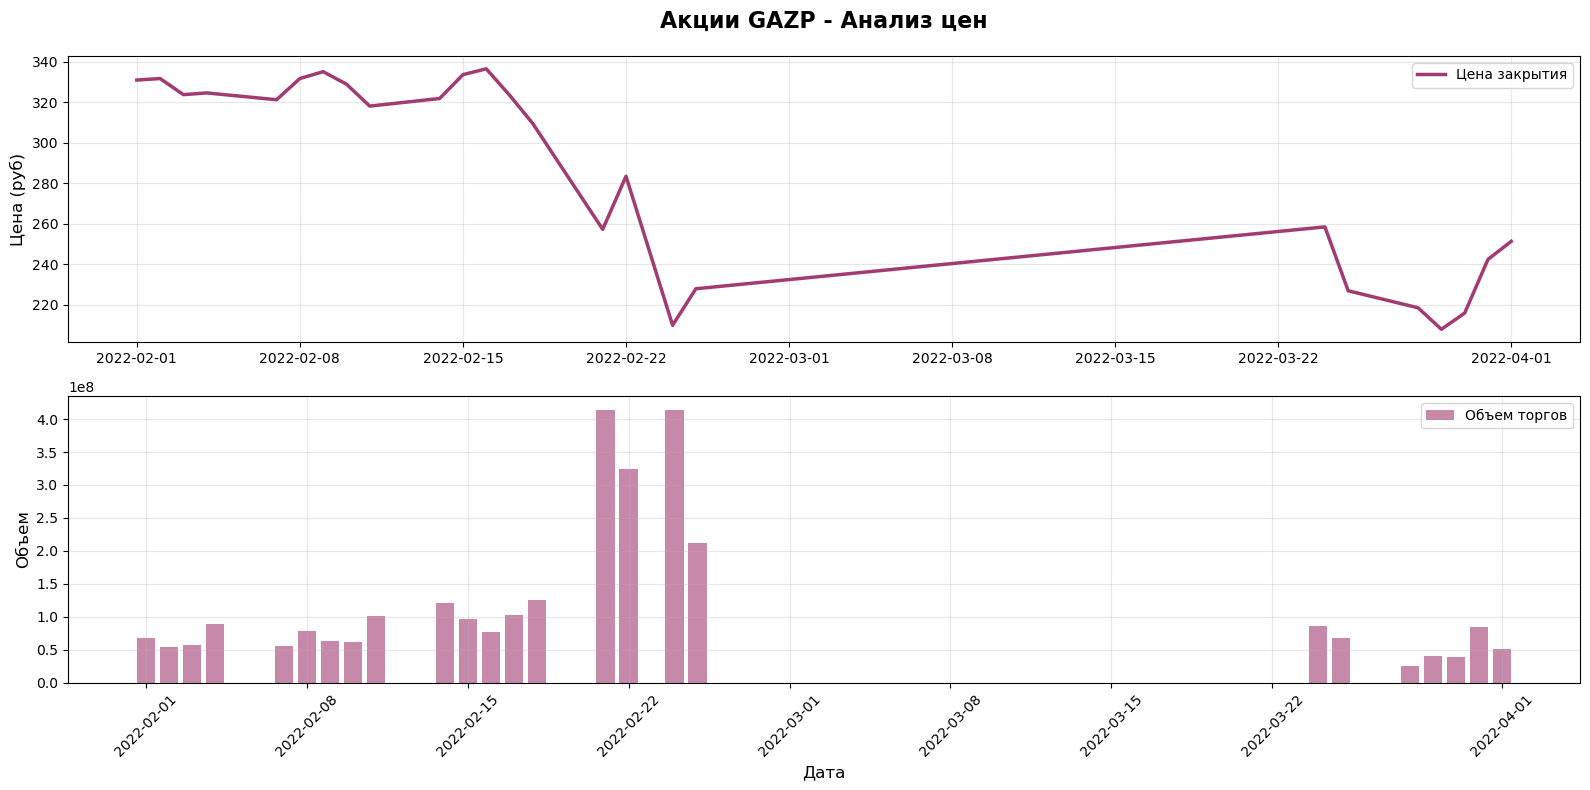

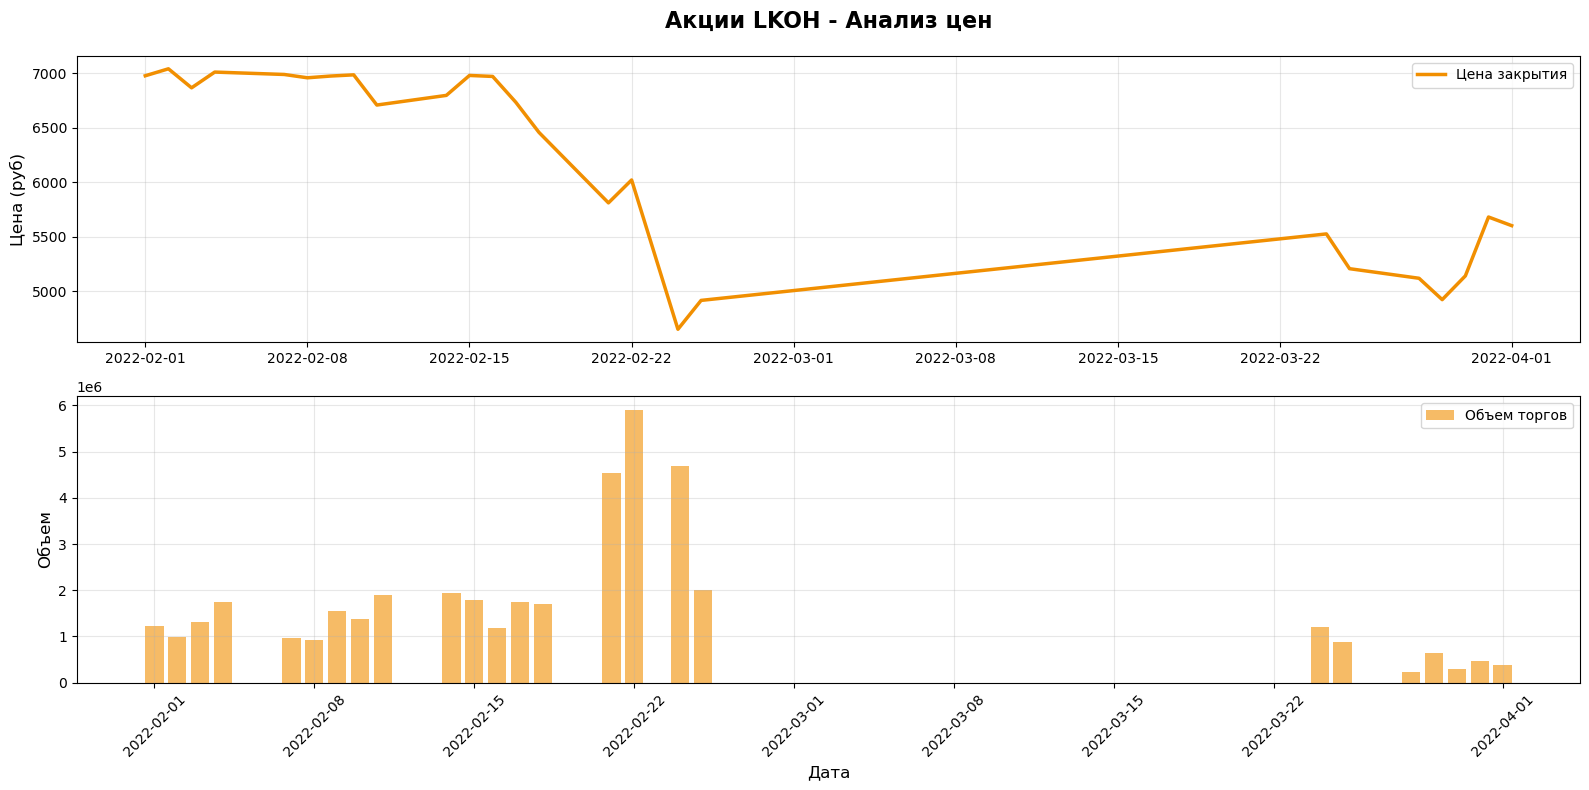

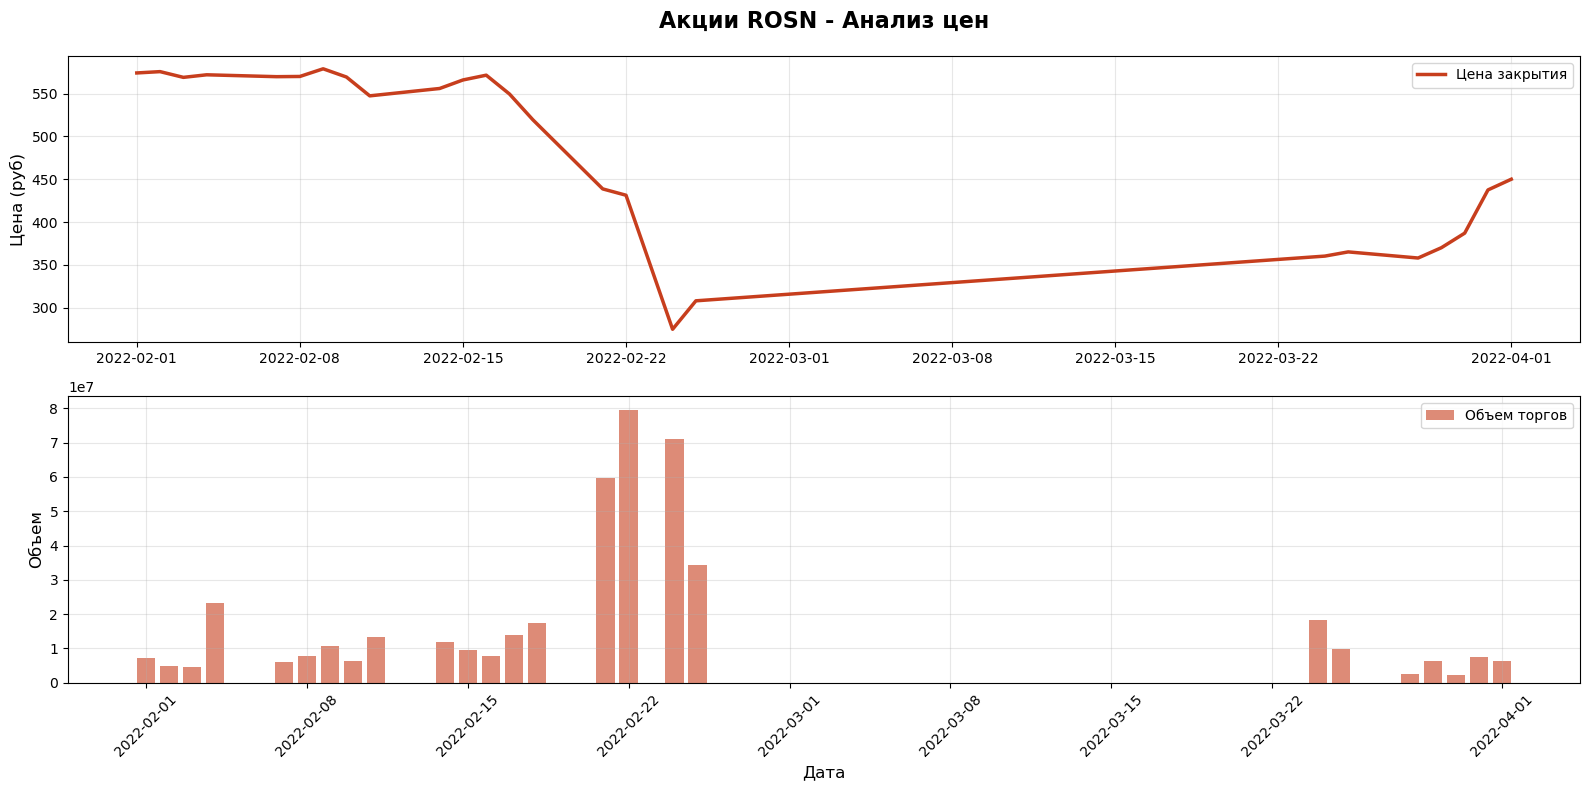

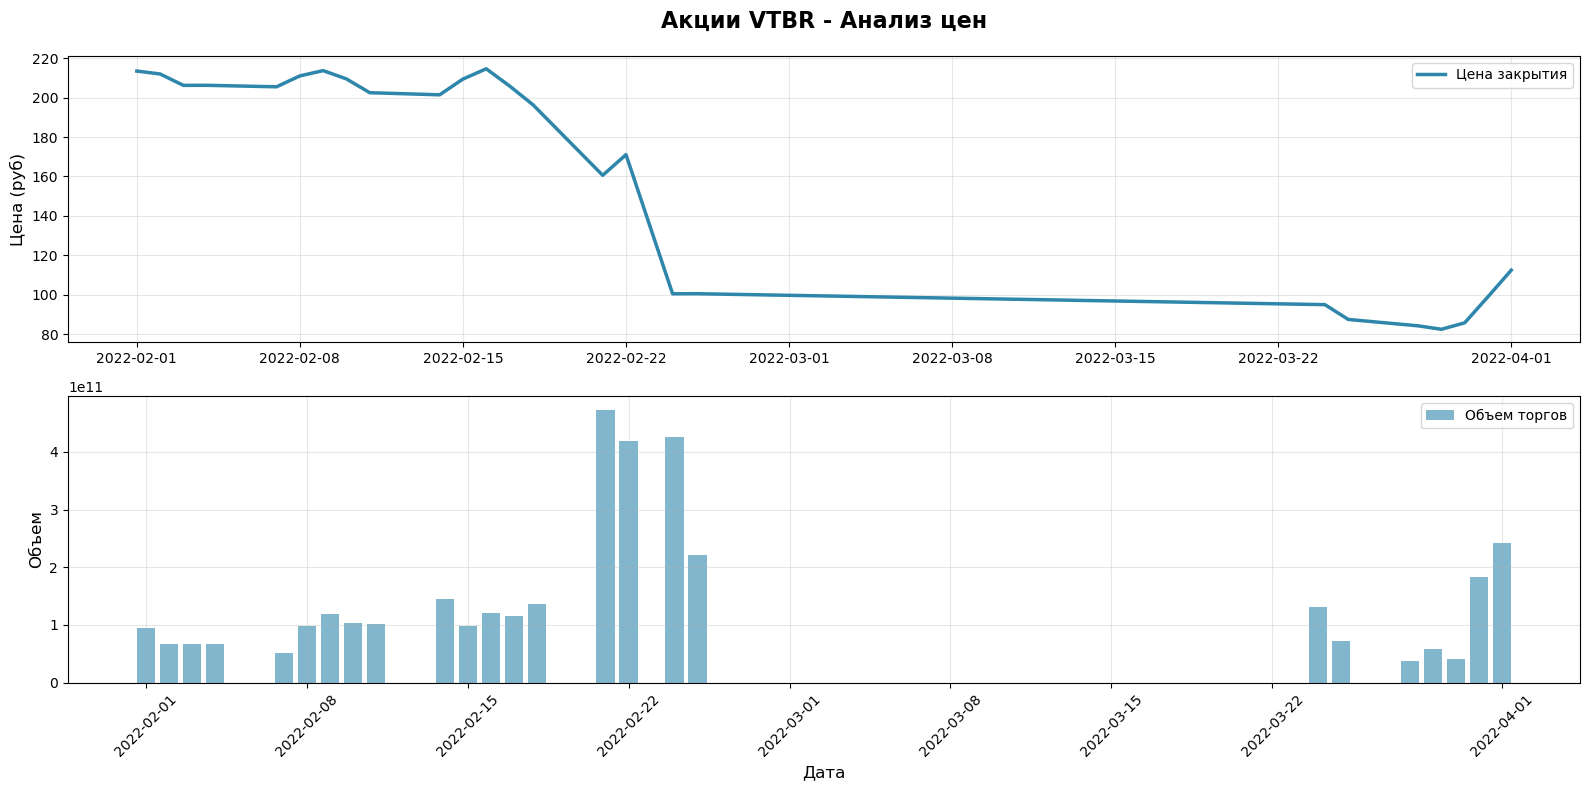

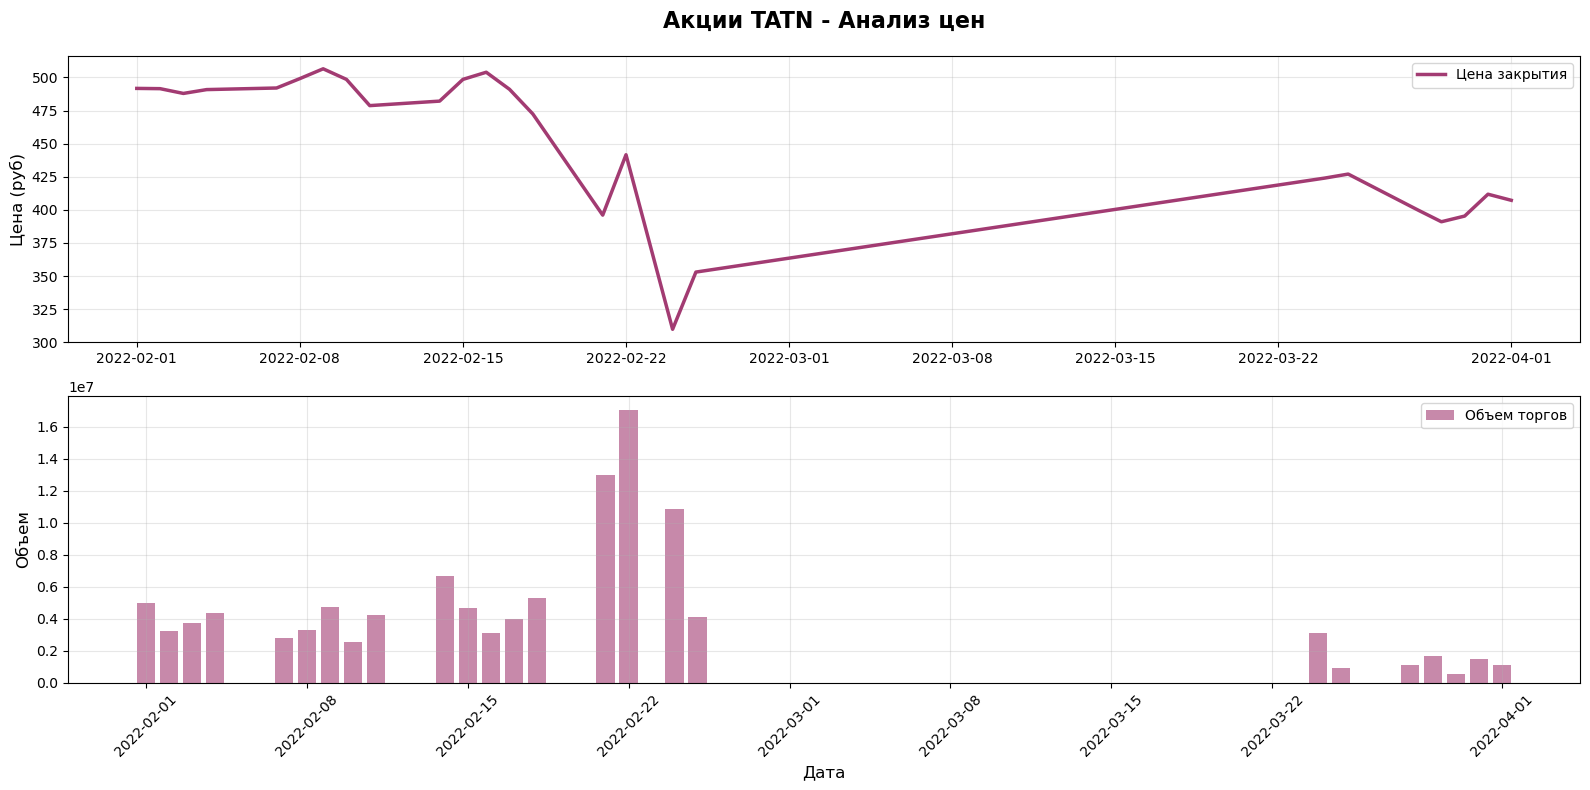

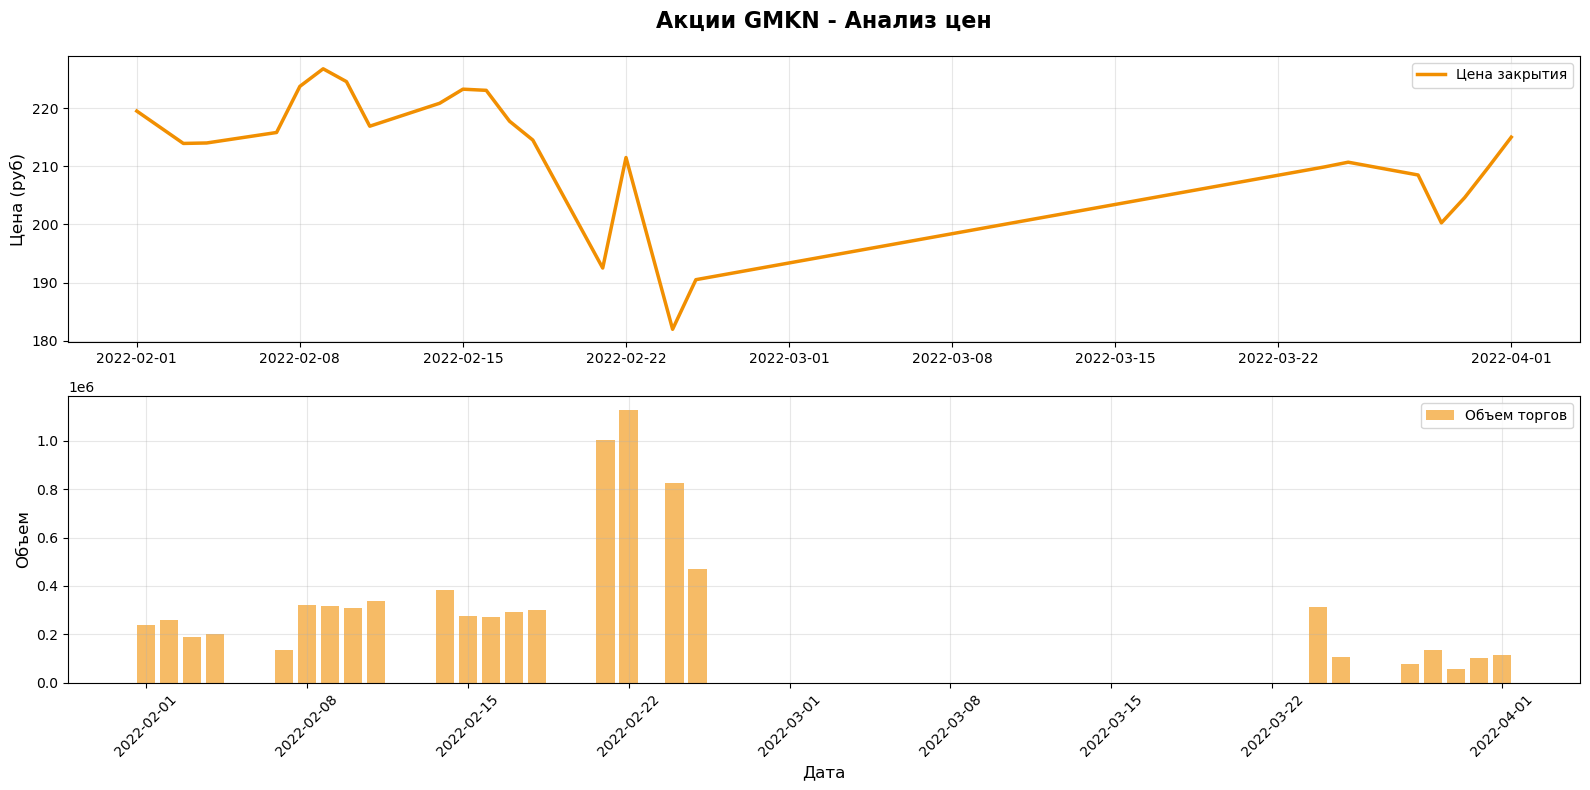

In [159]:
plot_enhanced_ticker_charts(stock_data_2022)

### 3.4.2 Анализ дат торгов

In [163]:
stock_data_2022['SBER'][stock_data_2022['SBER']['begin'] > '2022-02-18']

,begin,open,close,high,low,value,volume,ticker
14,2022-02-21,249.15,201.00,258.32,184.30,2.385837e+11,1084508440,SBER
15,2022-02-22,198.72,208.53,219.90,182.03,1.886633e+11,946020570,SBER
16,2022-02-24,187.54,132.18,187.54,89.59,9.828140e+10,829355880,SBER
17,2022-02-25,123.75,131.12,152.89,115.11,5.176981e+10,396287150,SBER
18,2022-03-24,131.00,136.24,156.20,130.15,2.269207e+10,159464350,SBER
19,2022-03-25,137.00,131.50,147.00,128.20,7.725368e+09,57662950,SBER
20,2022-03-28,130.60,125.00,131.47,125.00,4.203875e+09,33212430,SBER
21,2022-03-29,126.16,128.77,137.57,122.00,9.470337e+09,72338740,SBER
22,2022-03-30,136.89,134.60,138.40,131.11,4.754054e+09,35675450,SBER
23,2022-03-31,135.25,143.69,147.41,134.52,1.666945e+10,118425000,SBER


## Вывод

По датам торгов видно, что был период их закрытия с 2022-02-25 по 2022-03-24

В связи с этим фактом и высокой волотильностью после открытия торгов принято решение взять данные с начала мая 2022 года, чтобы избезать попадания данного промежутка и слишком спецэффичных данных в обучающую выборку для модели

## 3.5 Анализ данных (2022-05-01 : 2025-10-01), 3 года 5 месяцев

### 3.5.1 Визуализация

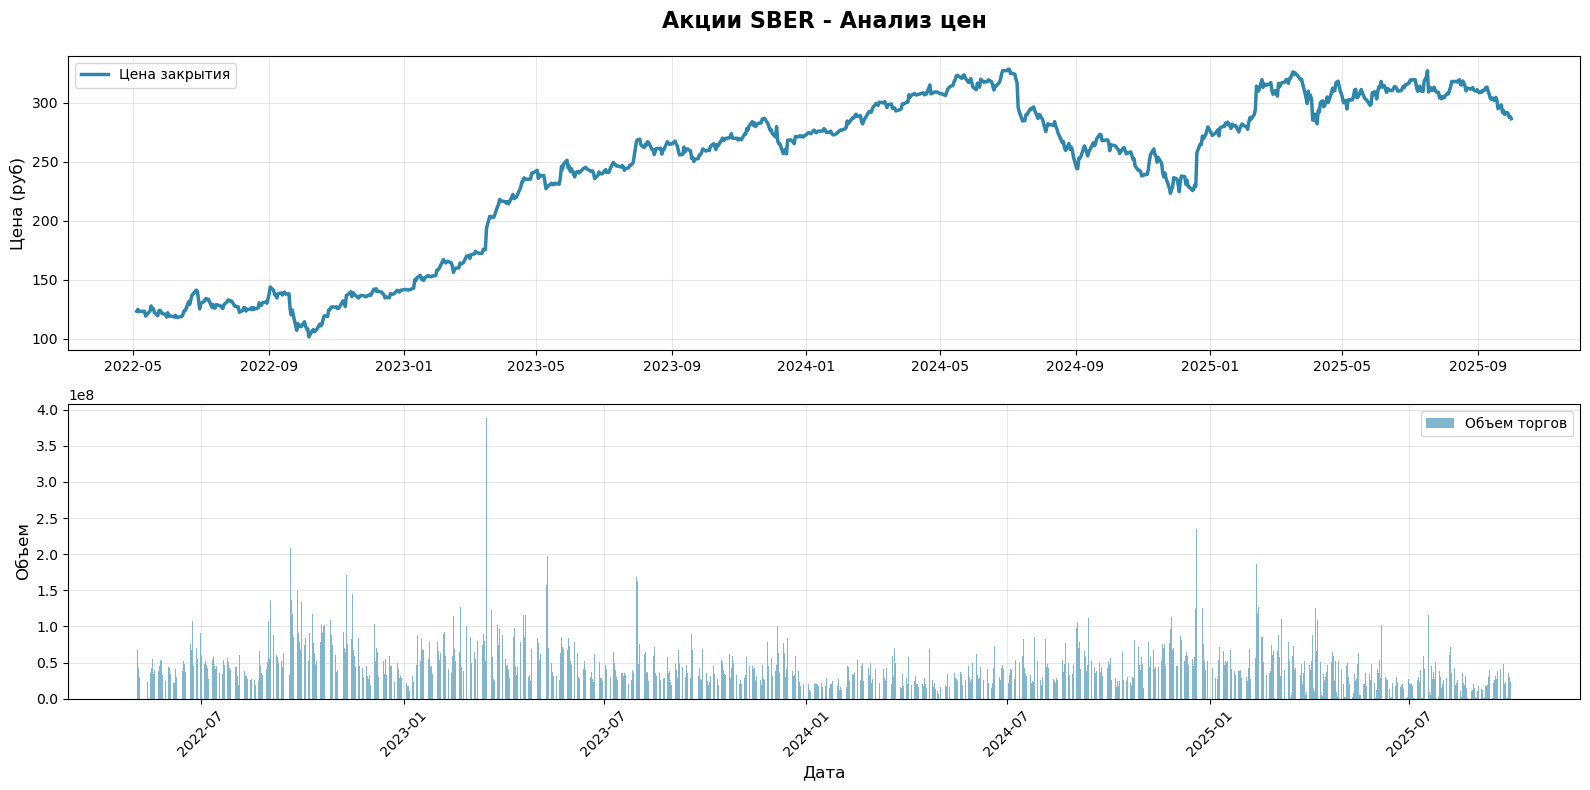

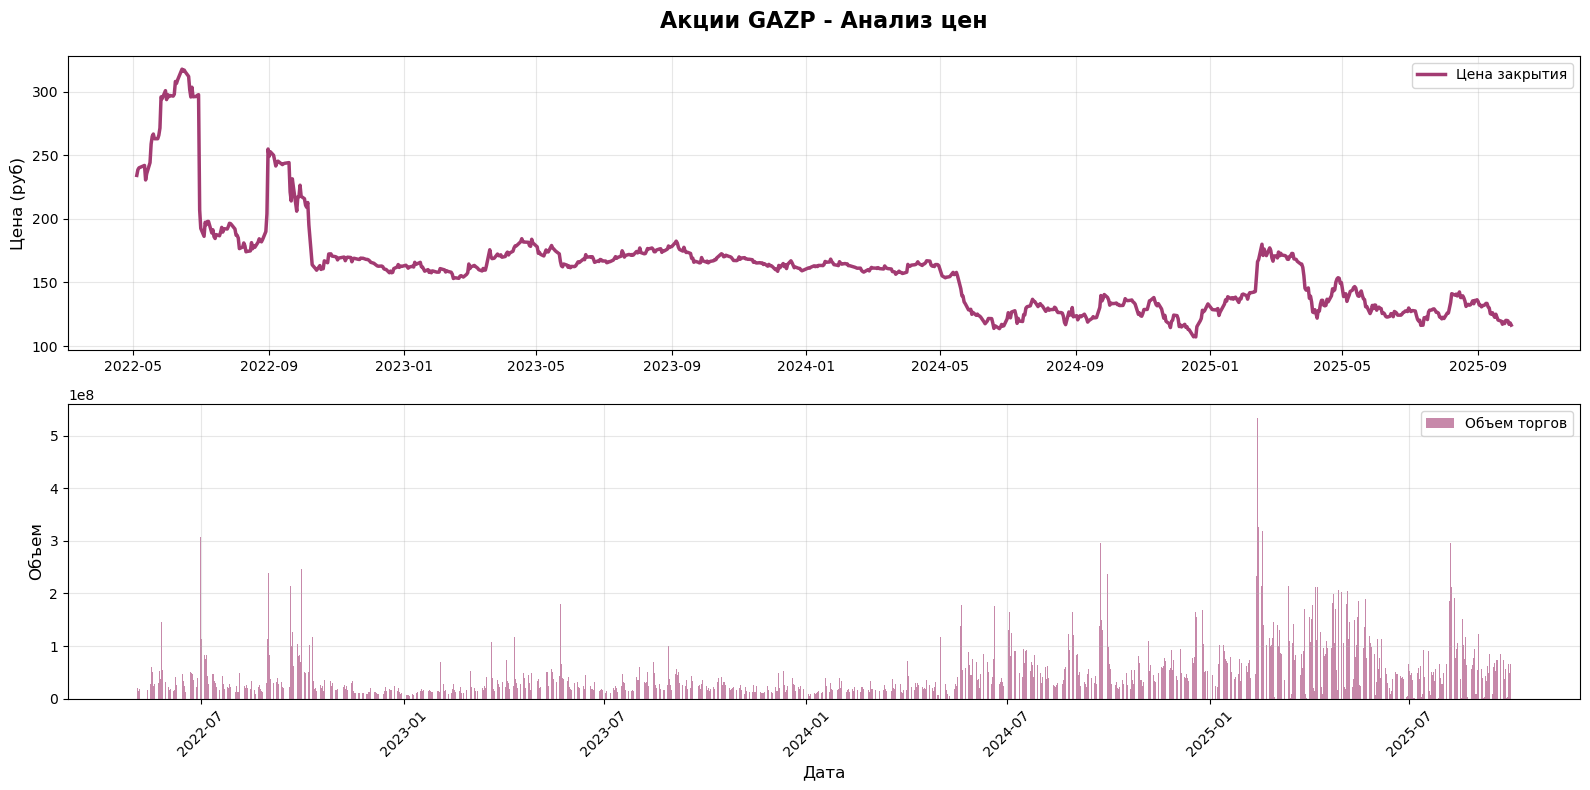

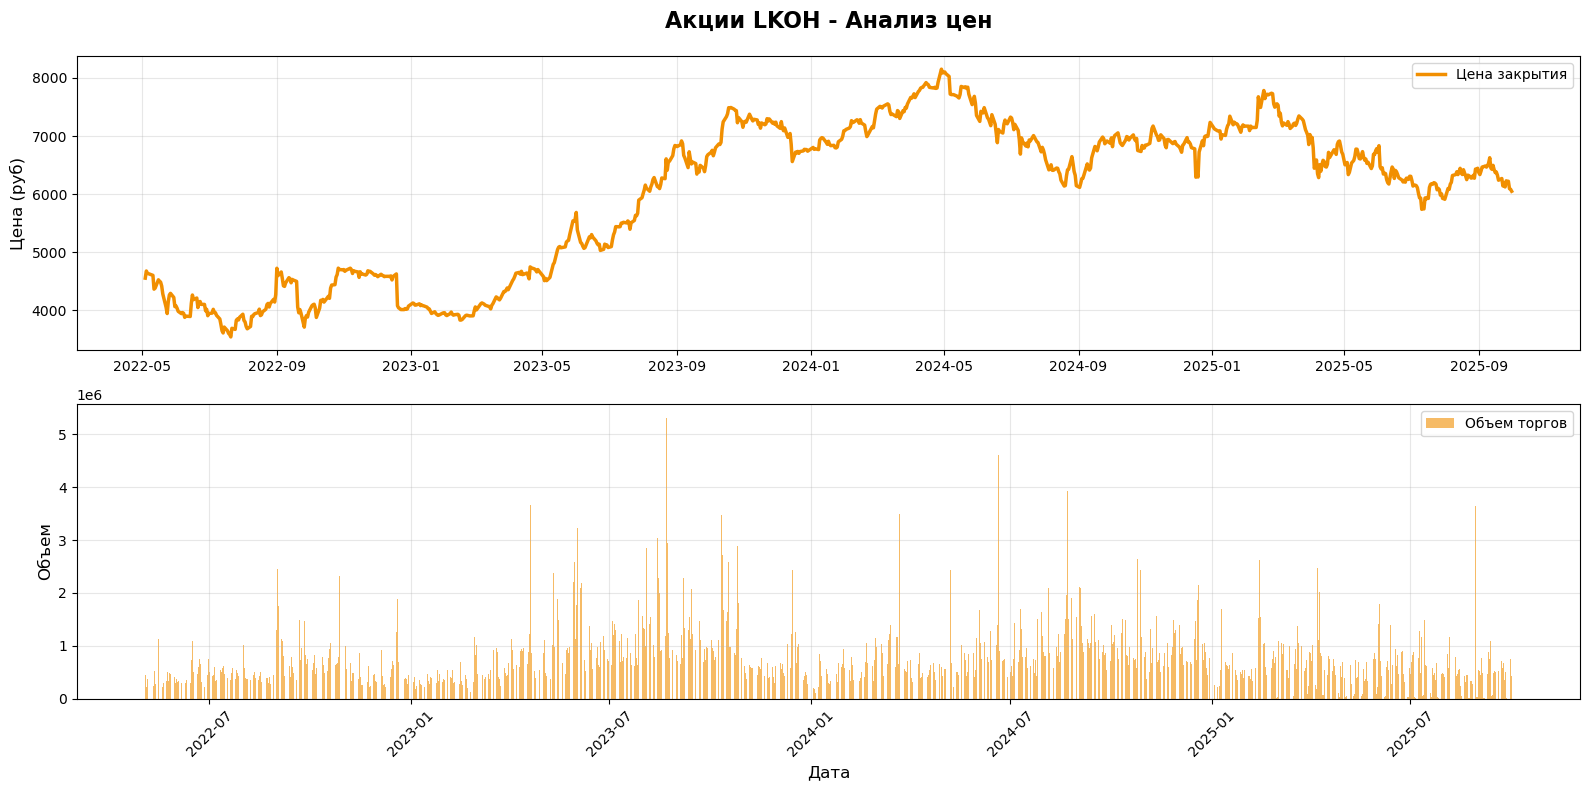

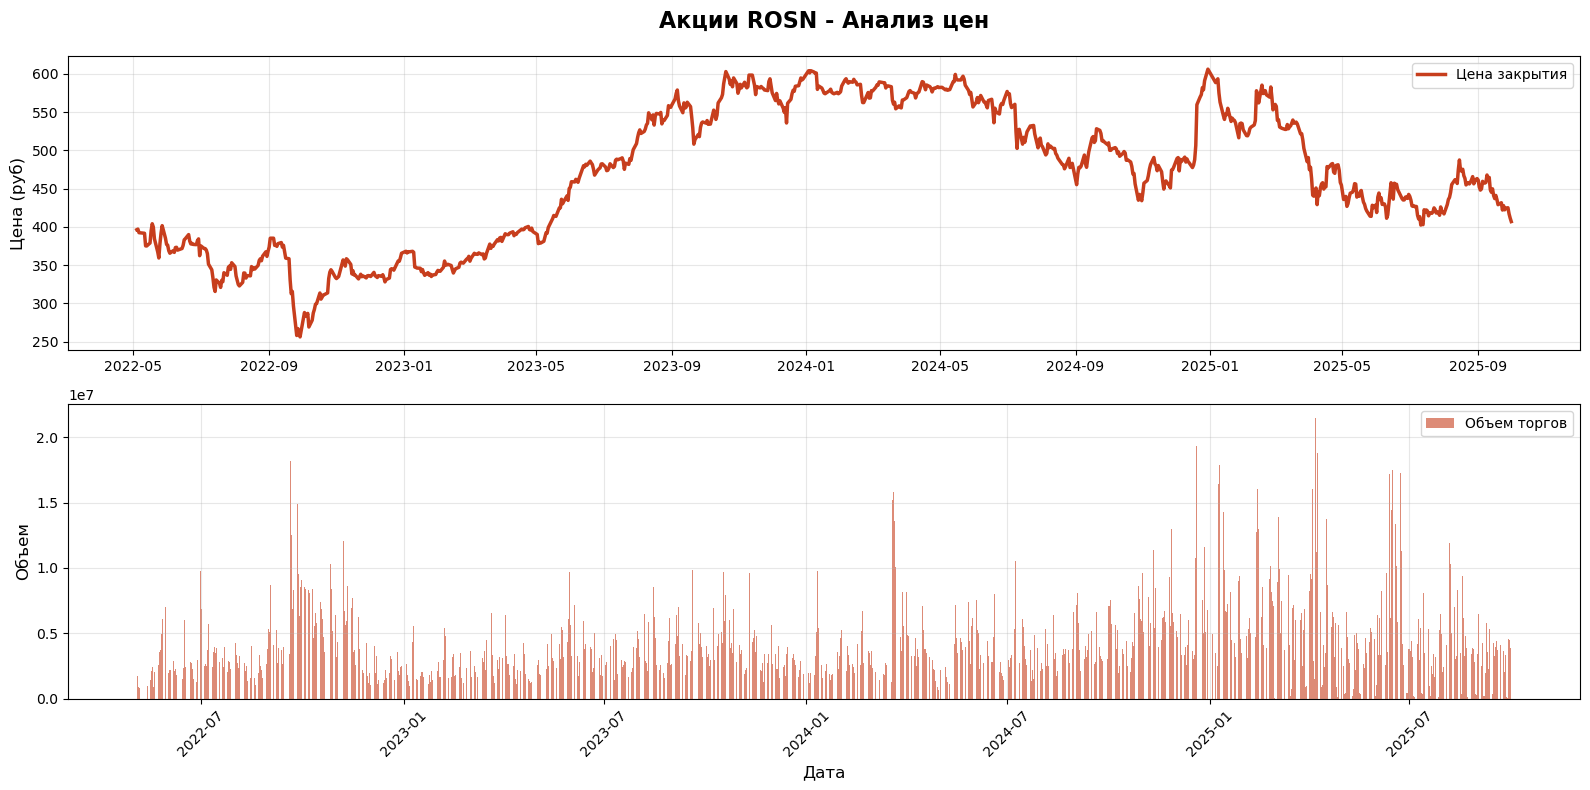

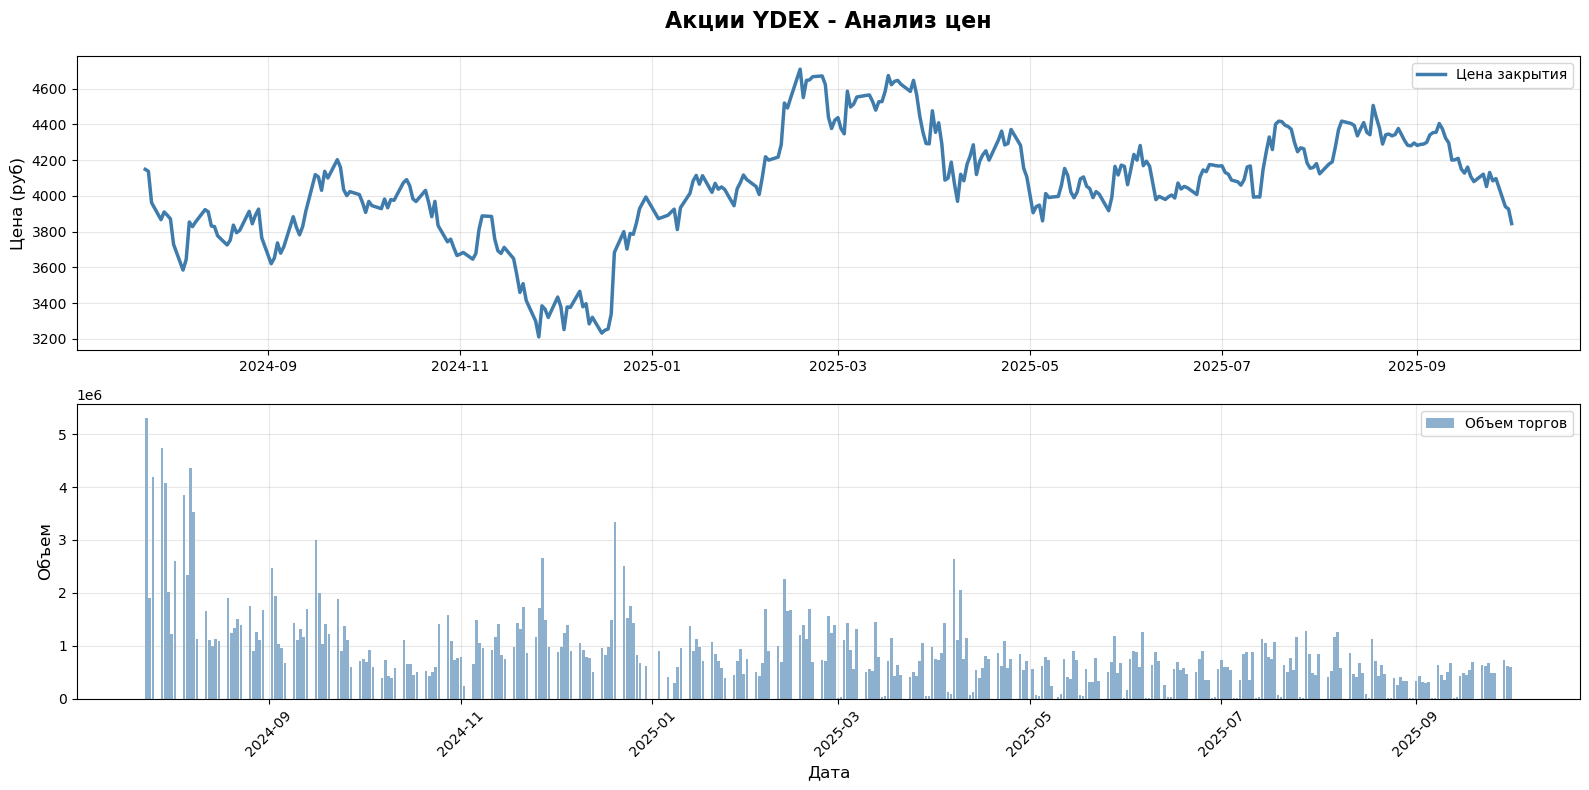

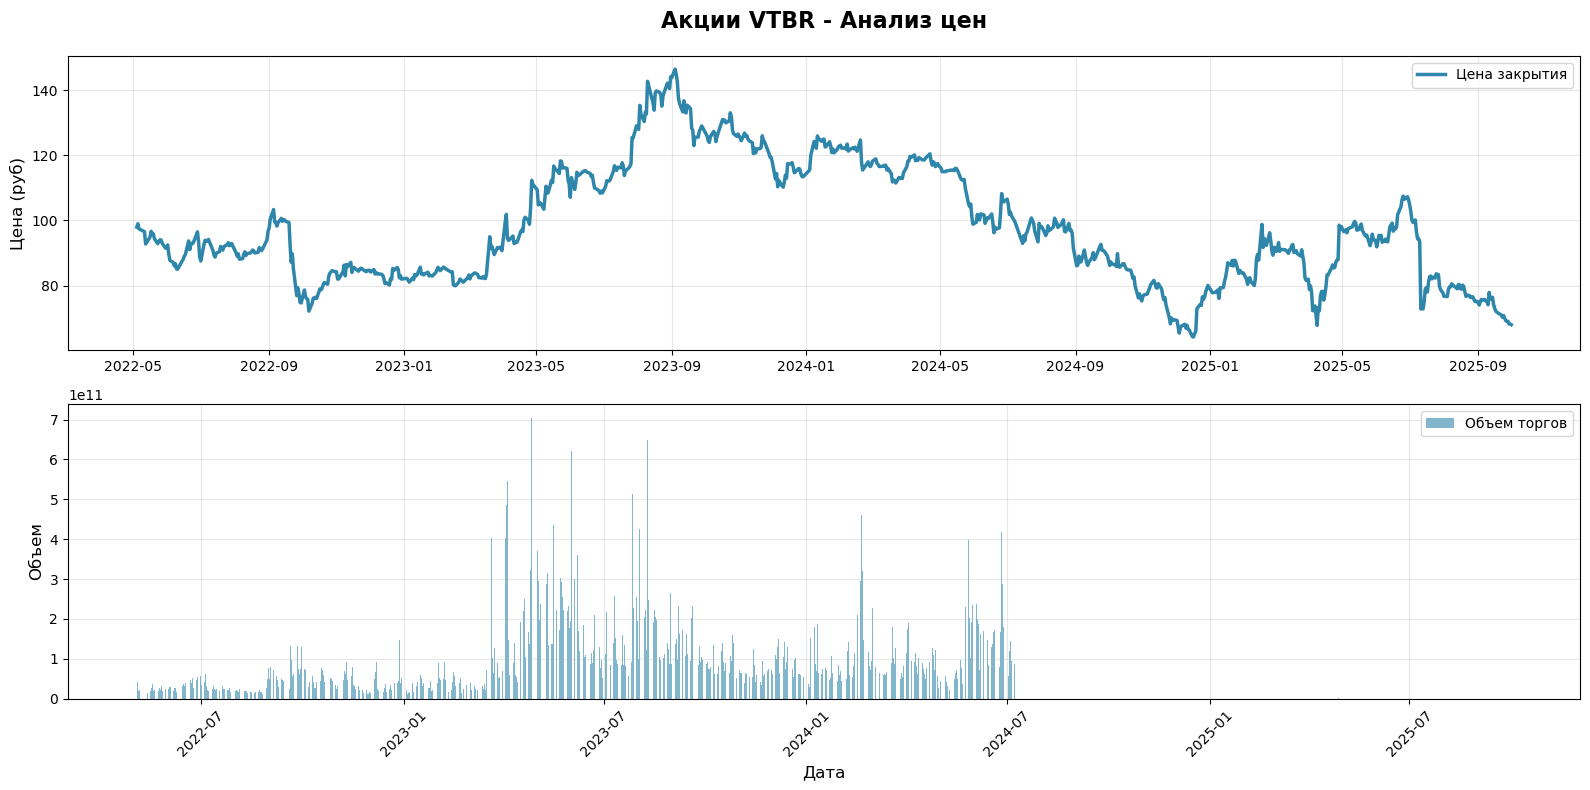

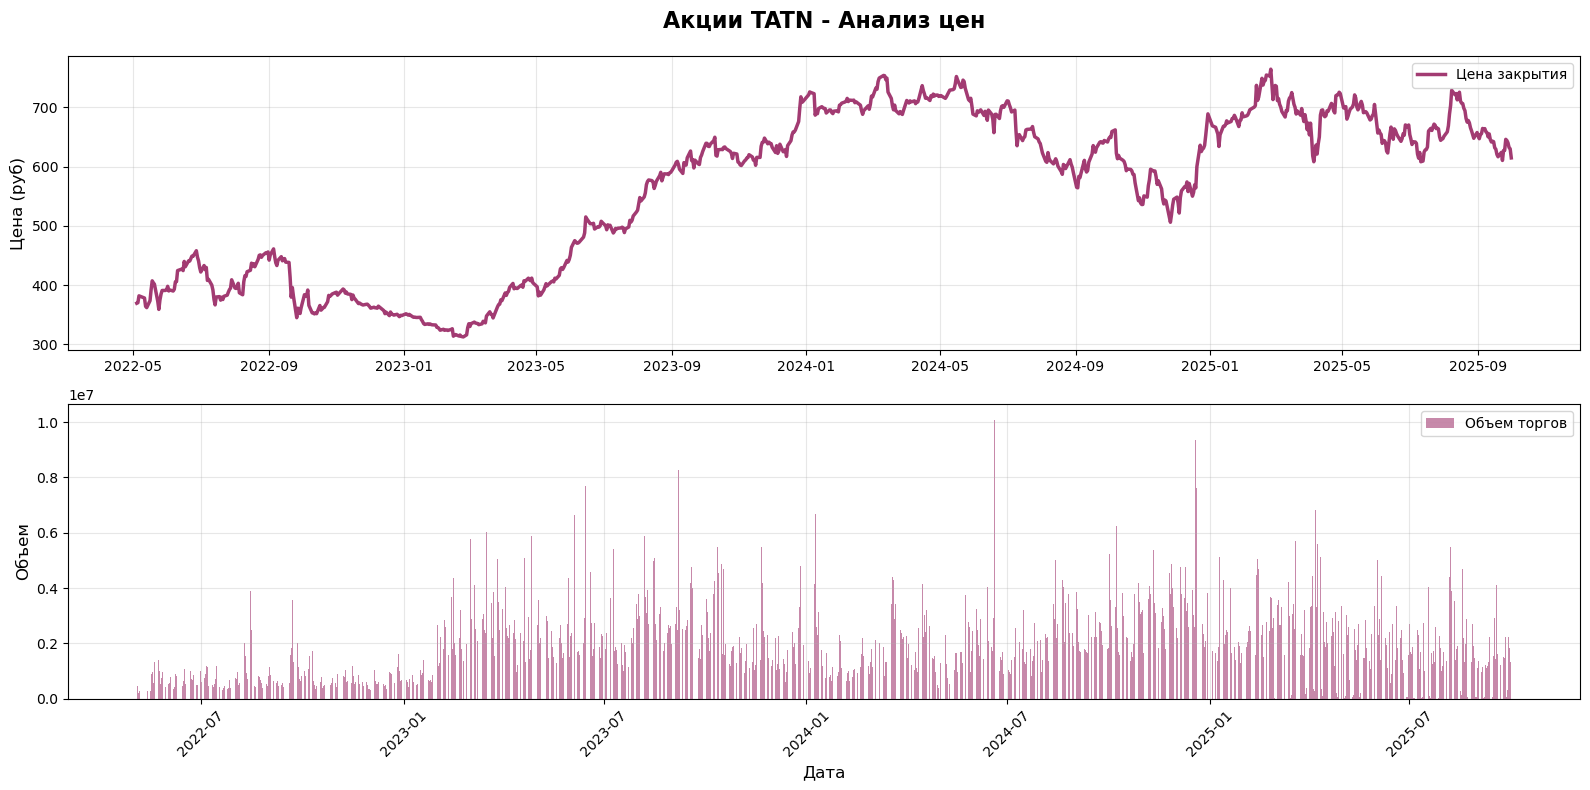

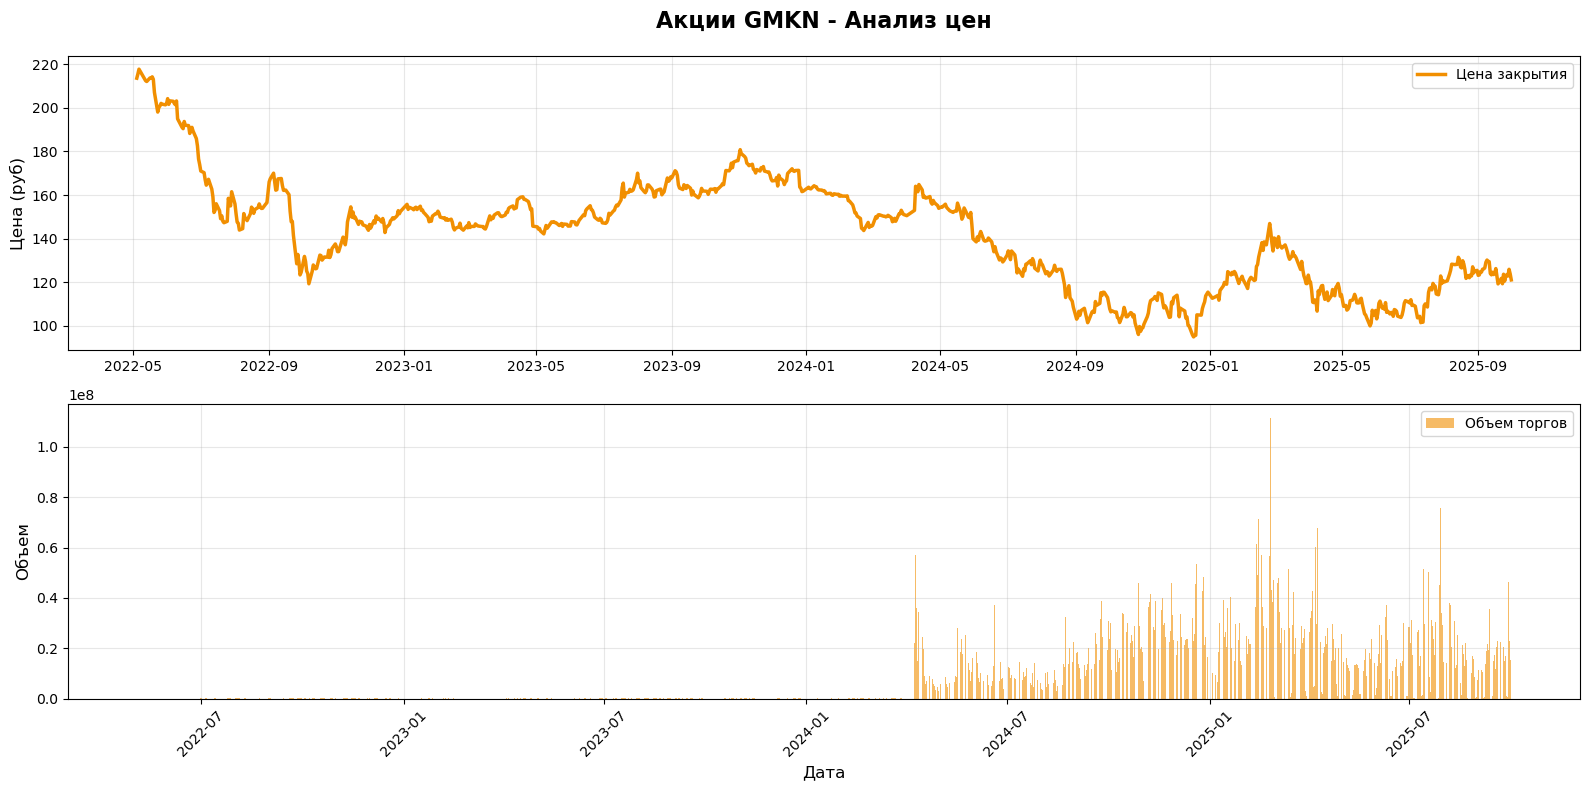

In [175]:
plot_enhanced_ticker_charts(stock_data_final)

### 3.5.2 Автокорреляционный анализ

#### 3.5.2.1 На всем промежутке вермени

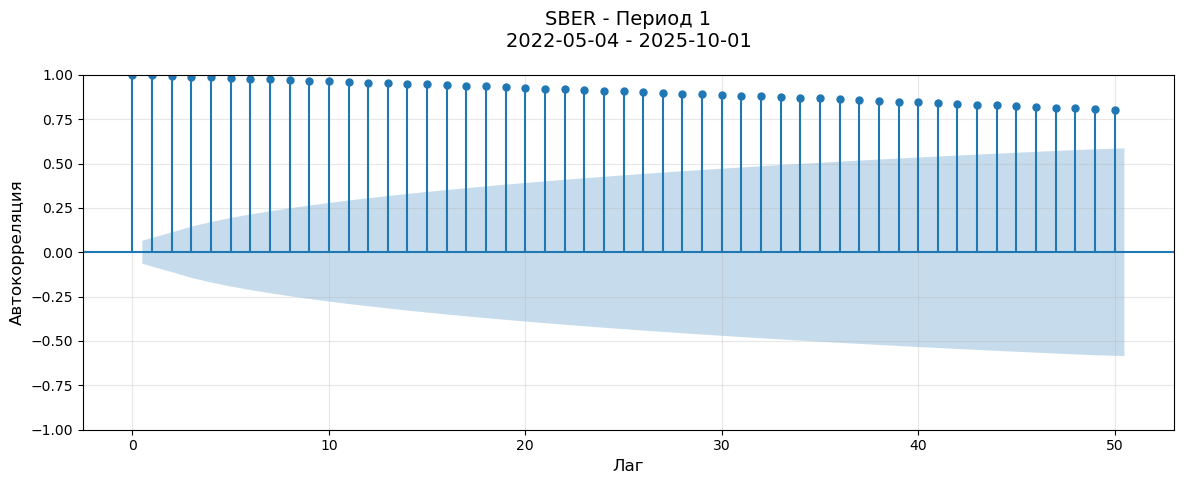

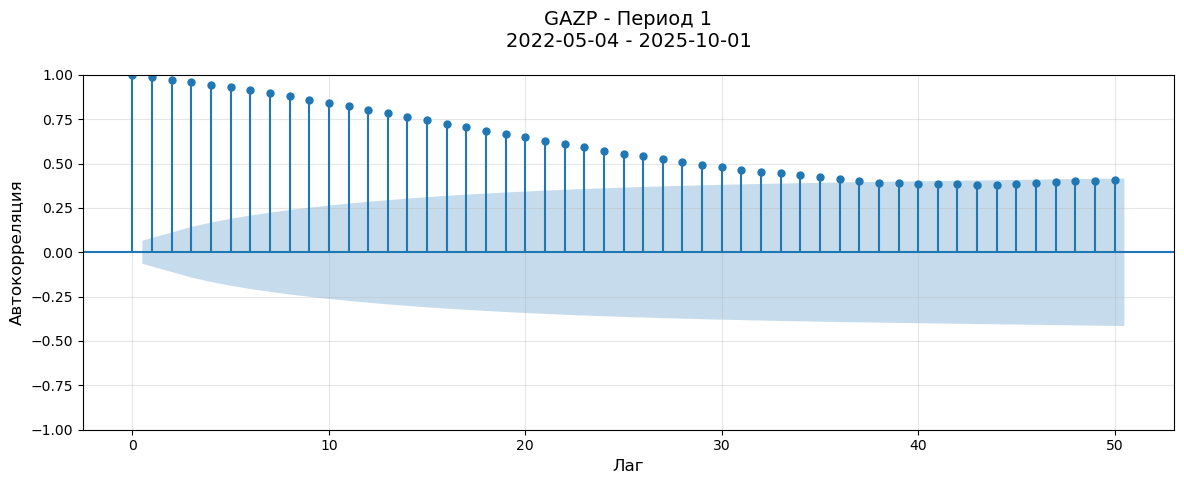

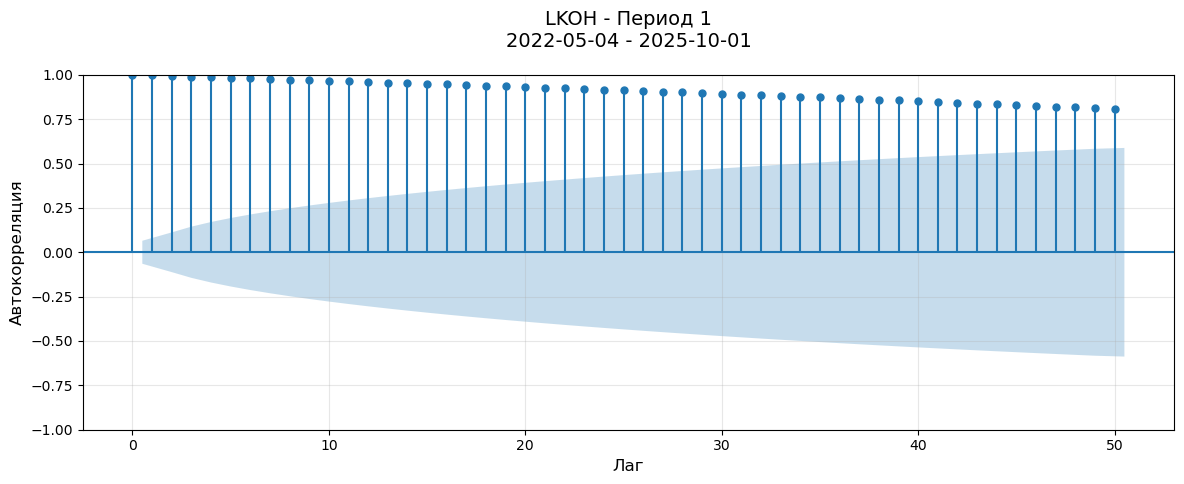

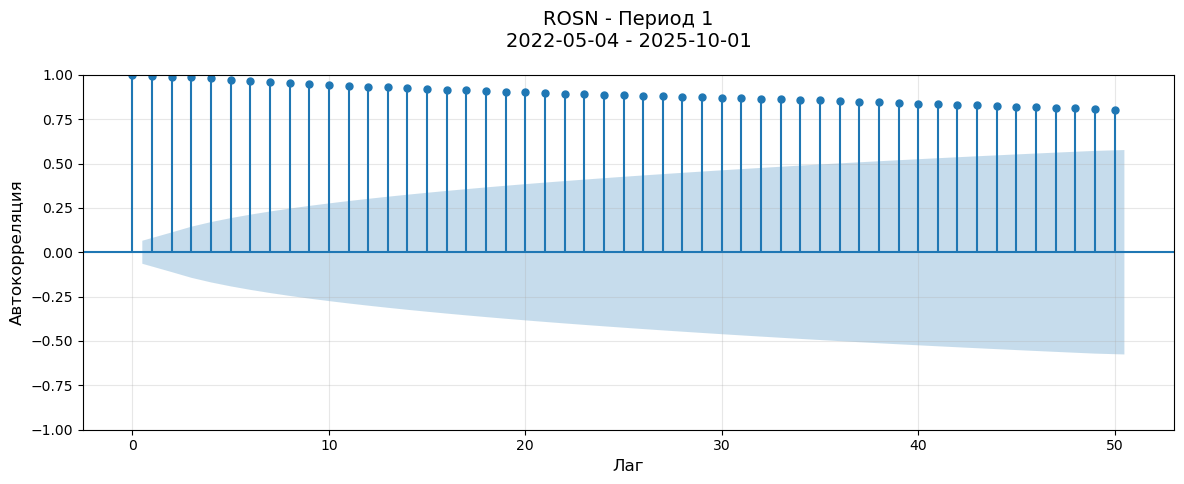

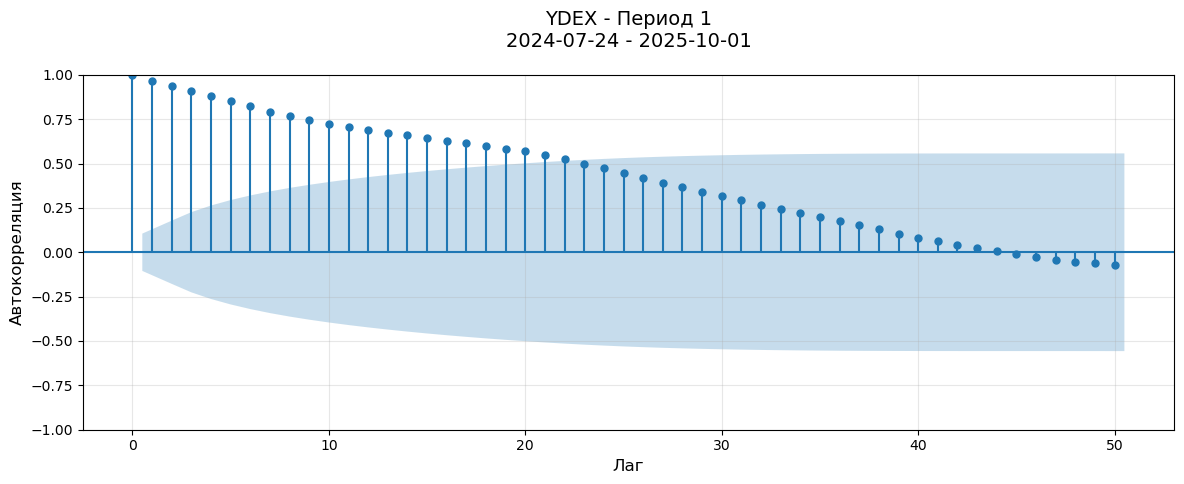

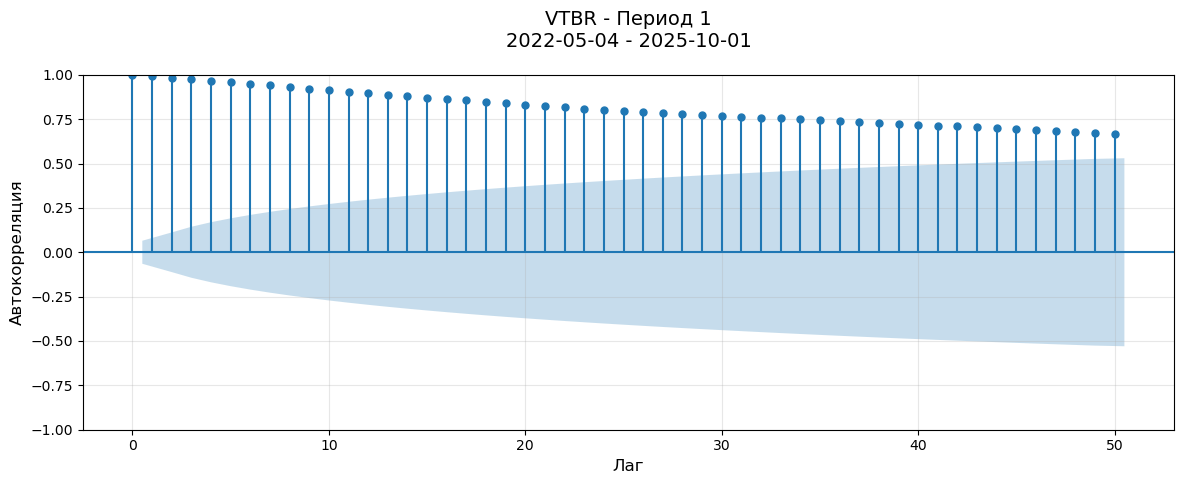

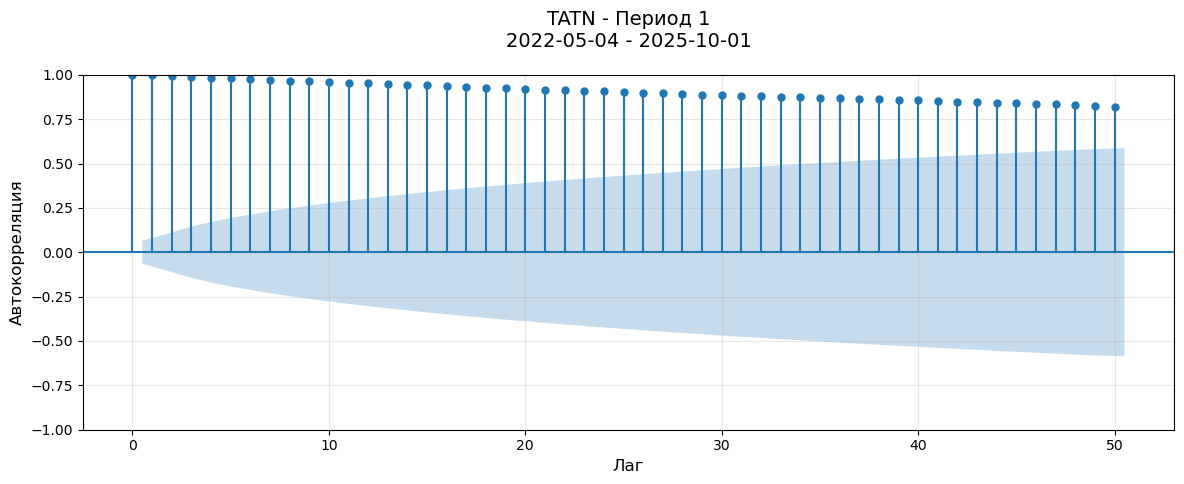

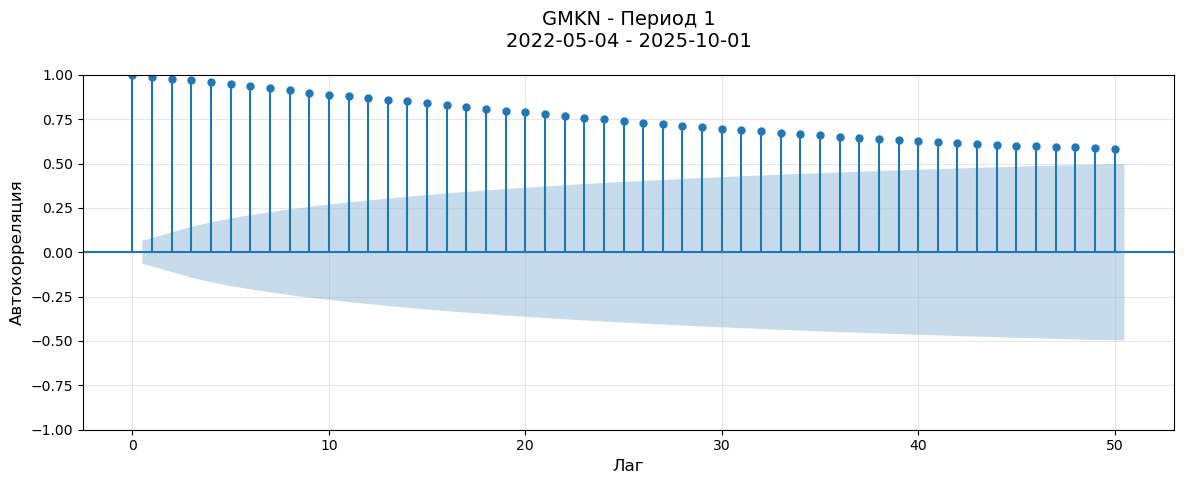

In [86]:
plot_autocorrelation_periods(stock_data_final, 1, 50)

#### Вывод

Медленное затухание значений автокорреляции показывают сильную трендовость и низкую волатильность </br>
Быстрое затухание, как у акций Яндекса, отражает высокую волатильность и то, что цена быстро инкорпорирует новую информацию </br>
Различные бумаги ведут себя по разному </br>
Если брать 10 или 20 лагов, то есть рассматривать влияние на краткосрочном промежутке веремени, то автокорреляция везде высокая

#### 3.5.2.2 На 2 равных промежутках

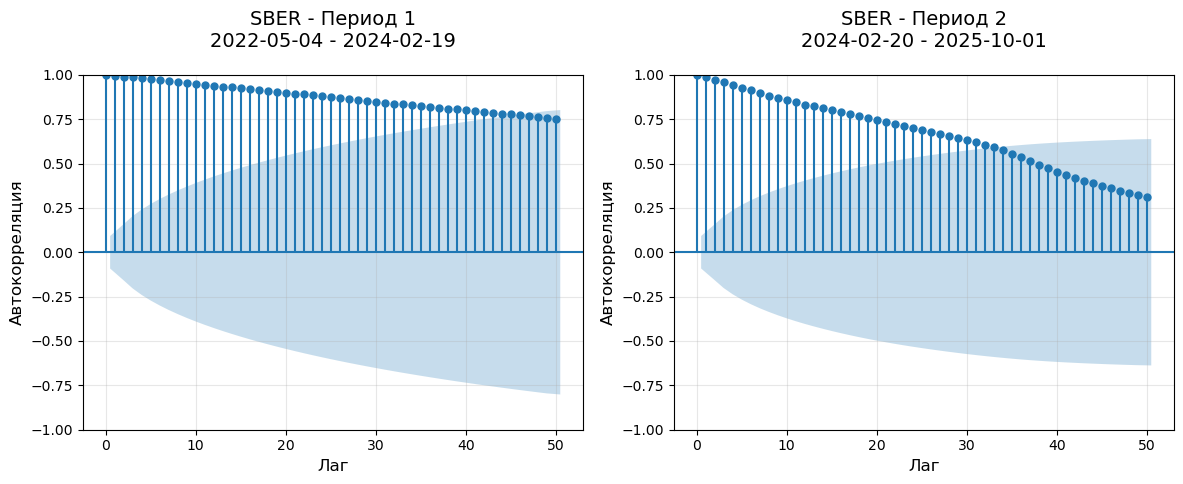

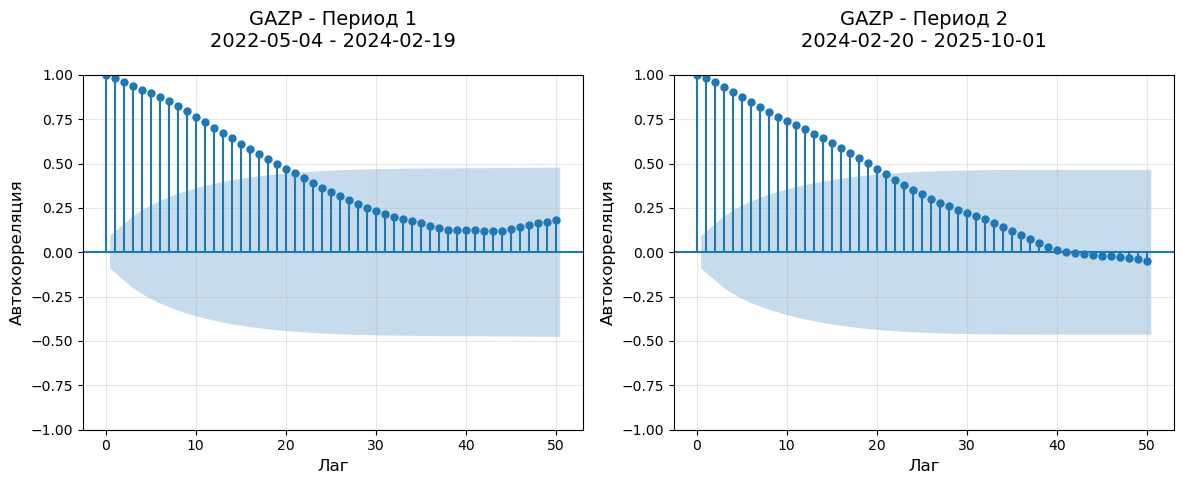

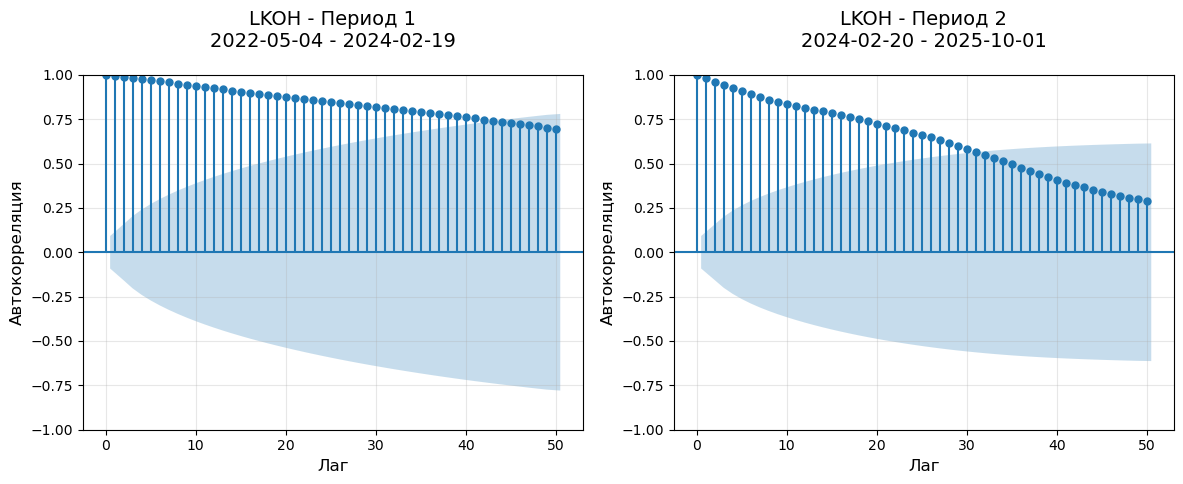

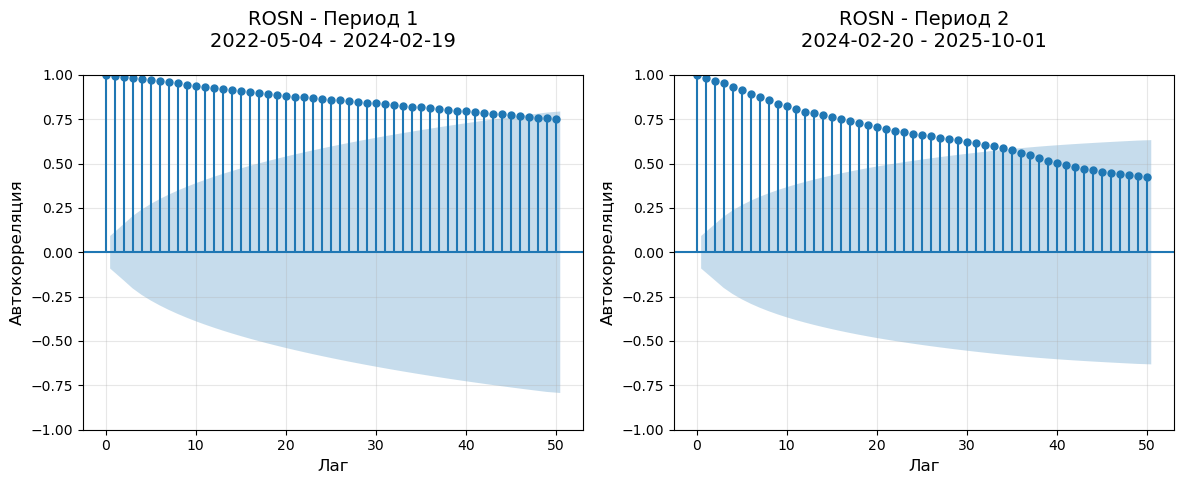

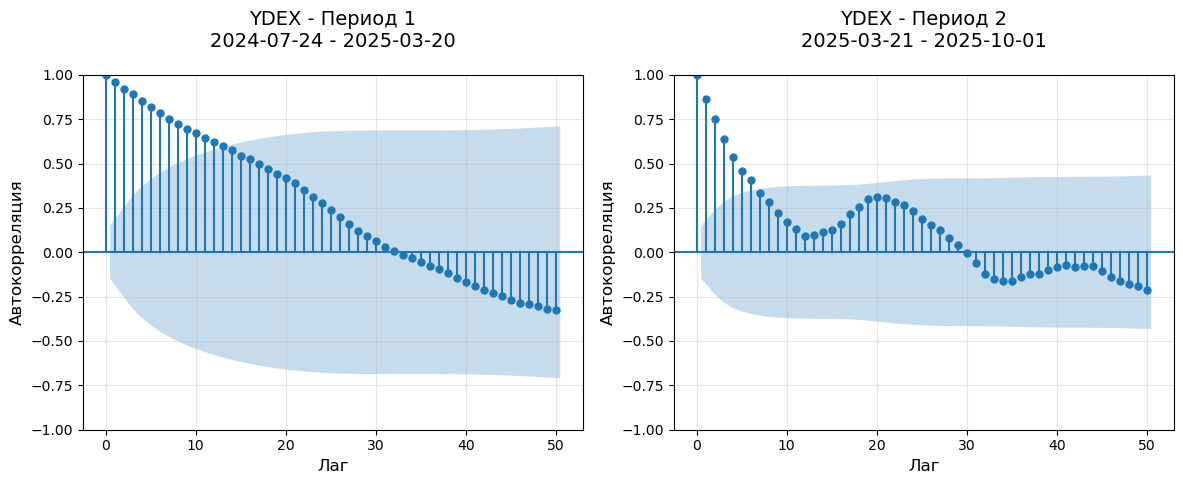

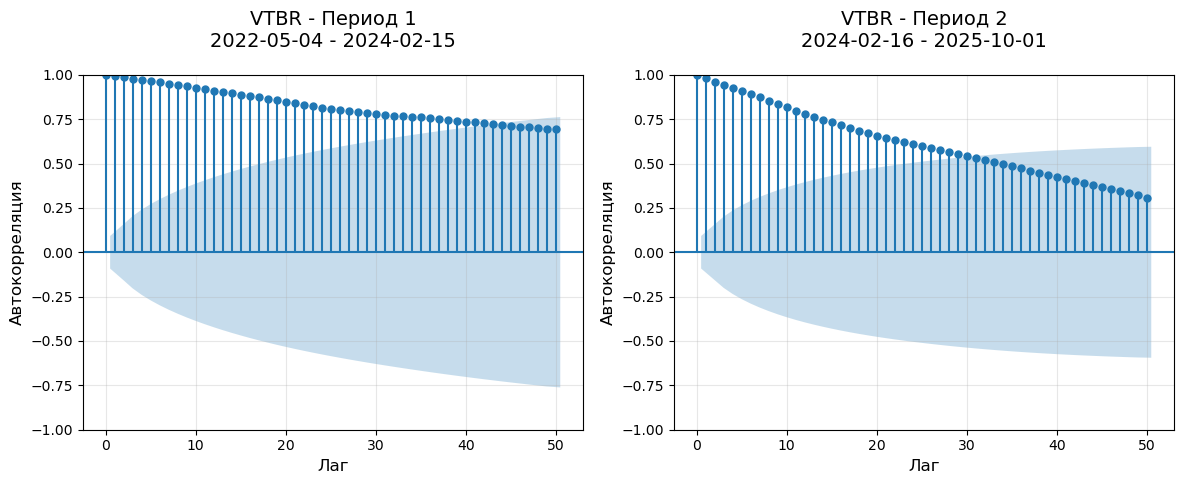

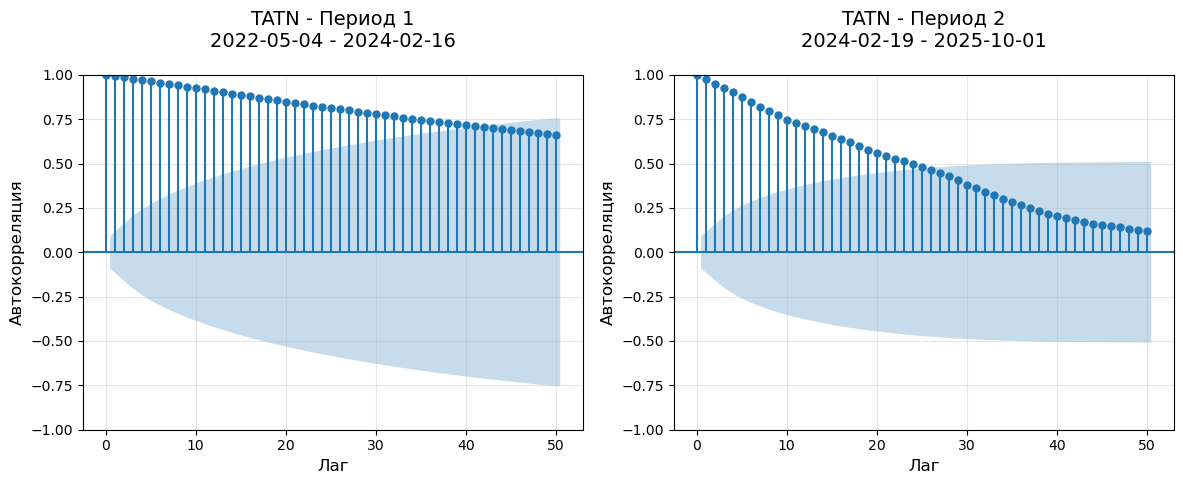

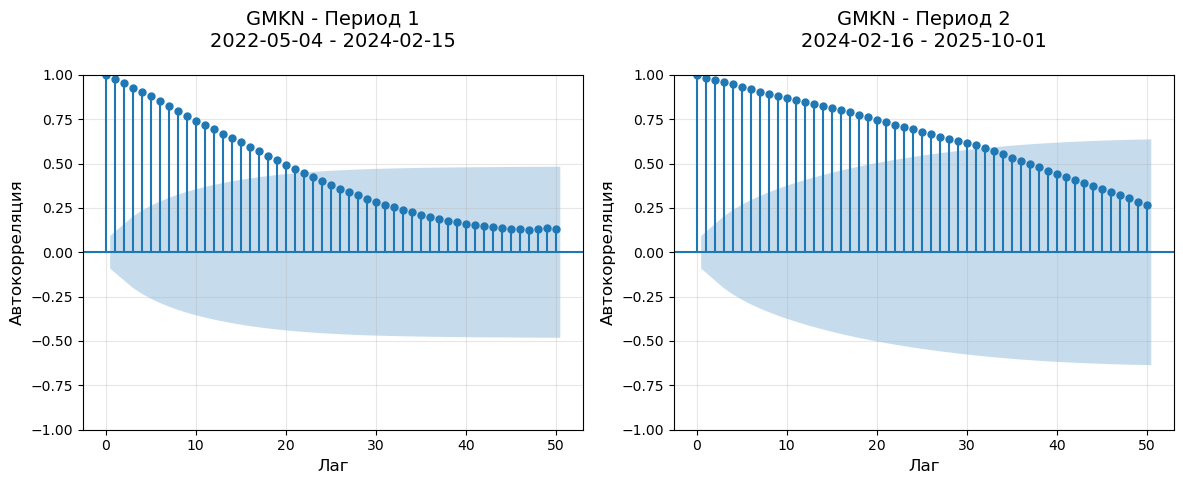

In [88]:
plot_autocorrelation_periods(stock_data_final, 2)

#### 3.5.2.2 На 3 равных промежутках

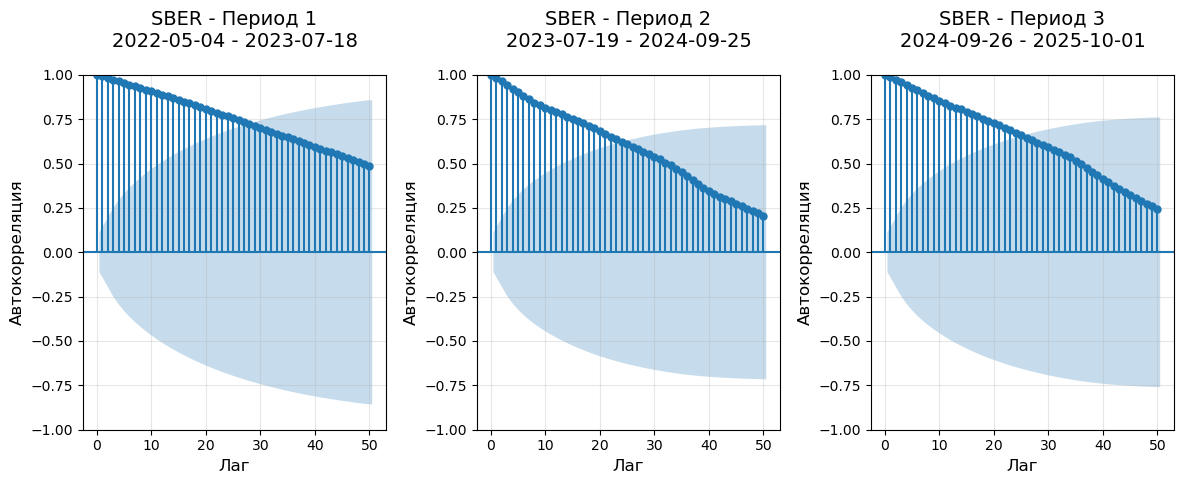

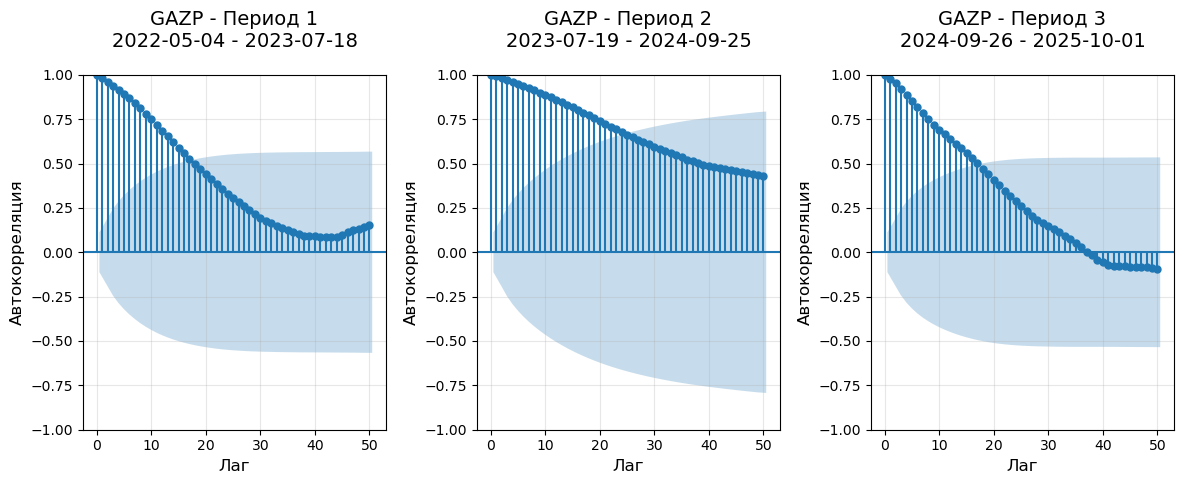

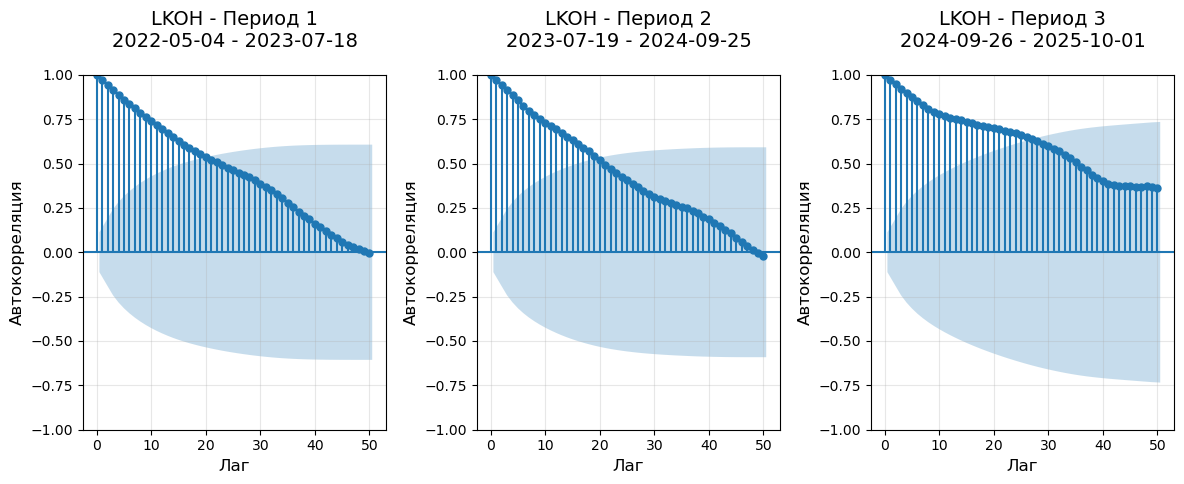

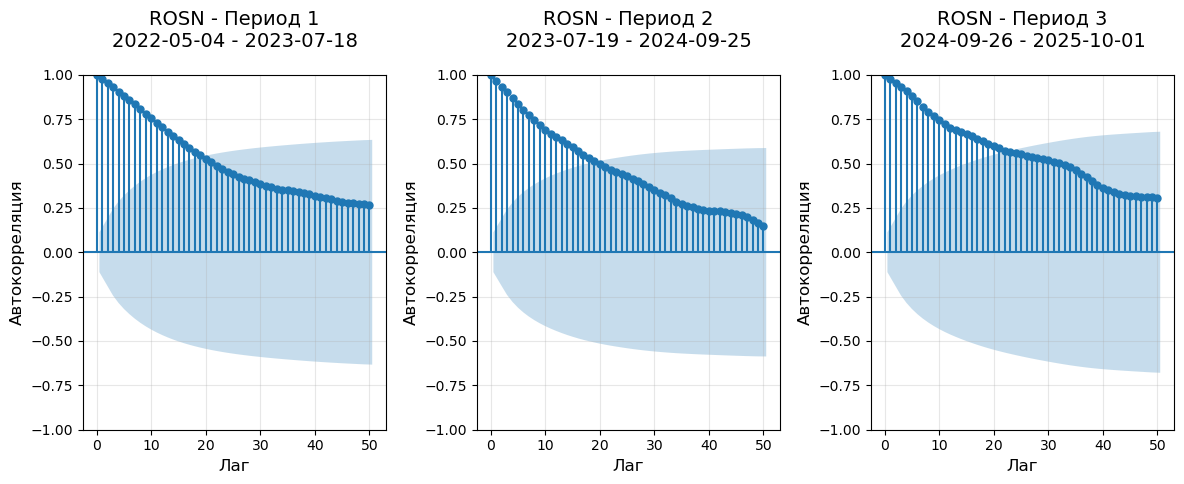

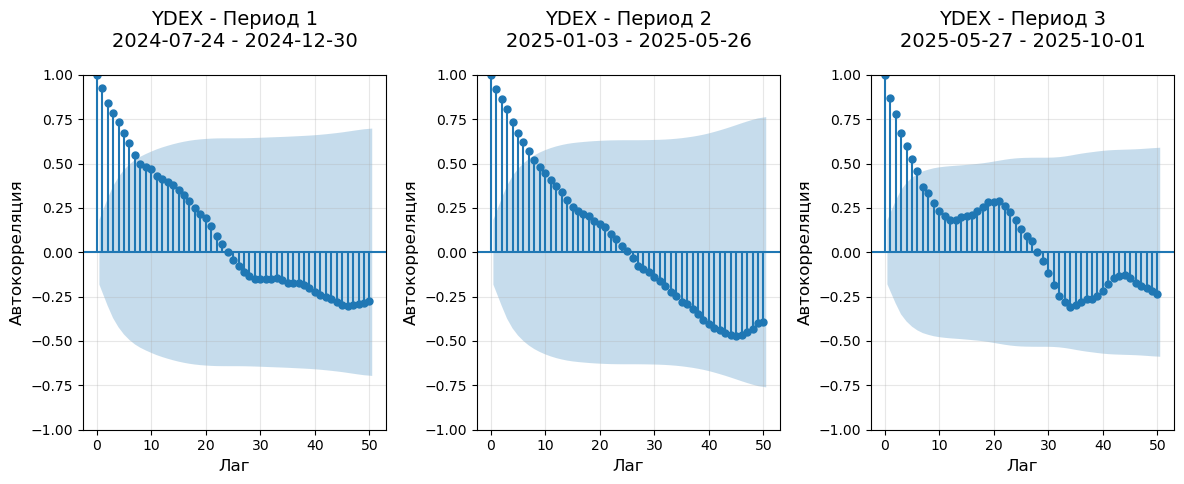

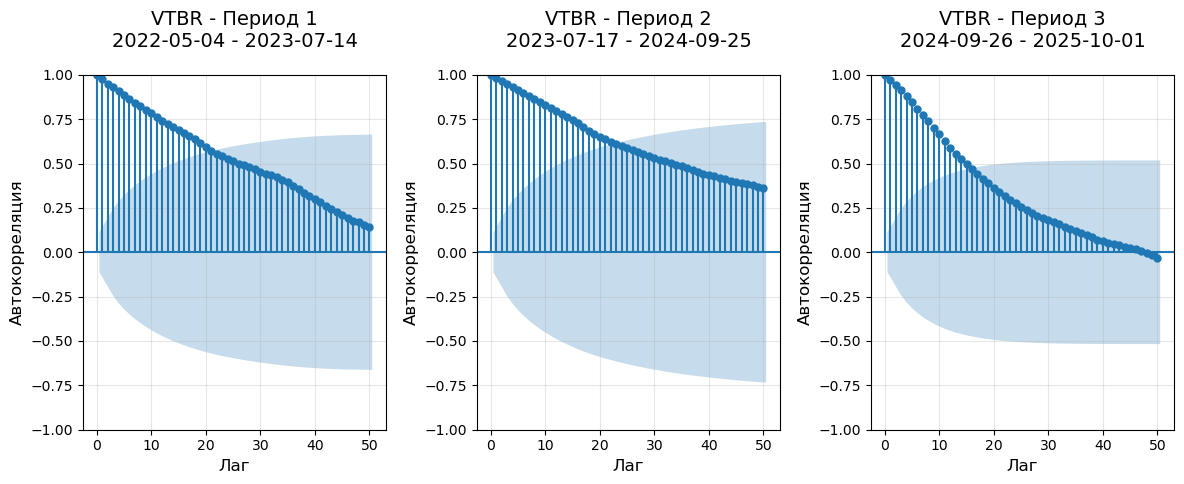

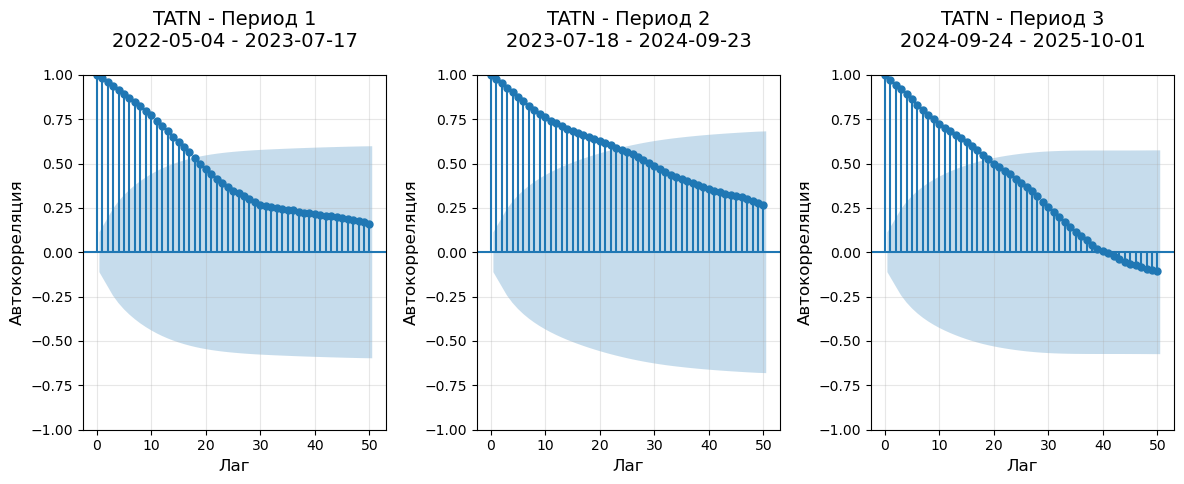

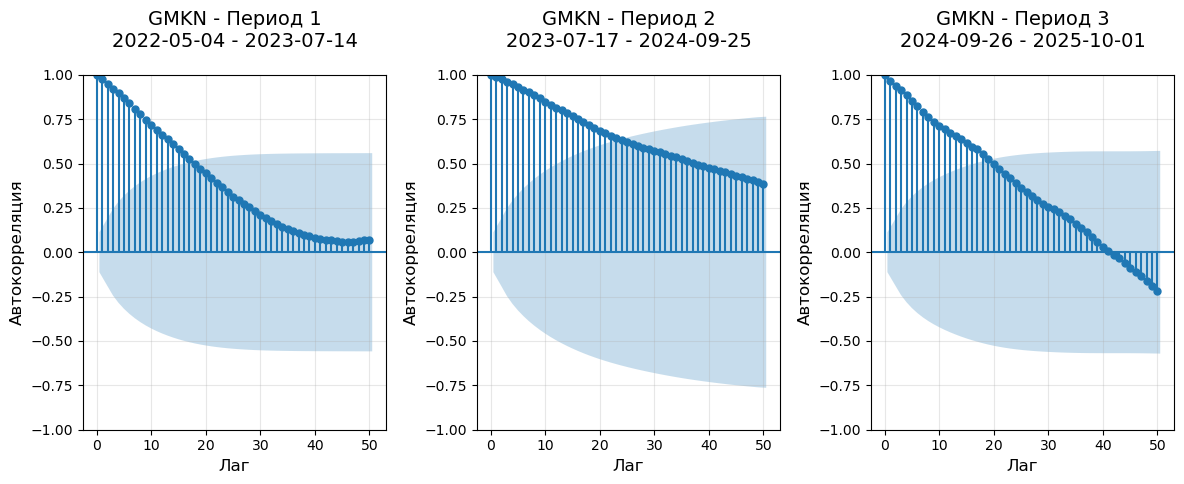

In [91]:
plot_autocorrelation_periods(stock_data_final, 3)

#### Вывод

Медленное затухание значений автокорреляции на всех промежутках встречается уже не у всех акций </br>
Примерно у половины поведение автокорреляции меняется в различные периоды времени

## Вывод

Кажется, что если в одинаковые моменты времени, то есть в одинаковых условиях рынка поведение у акций (автокорреляци) сильно отличаются, то одна общая модель для всех акций может работать плохо </br> 
В таком случае можно:
<ul>
    <li>Разделить акции на группы по паттернам автокорреляции </li>
    <li>Обучать отдельные модели для каждой группы </li>
    <li>Или добавить тип акции как признак </li>
    <li>Использовать даптивные окна признаков </li>
</ul>
С другой стороны, анализируется достаточно много лагов автокоррляции (50+), хотя предсказываться будет достаточно краткосрочный период, а если расматривать последние 10 лагов для каждой акции, то там везде стабильно высокая автокорреляция

### 3.5.3 Сравнение волотильности

#### 3.5.3.1 Окно 50 дней

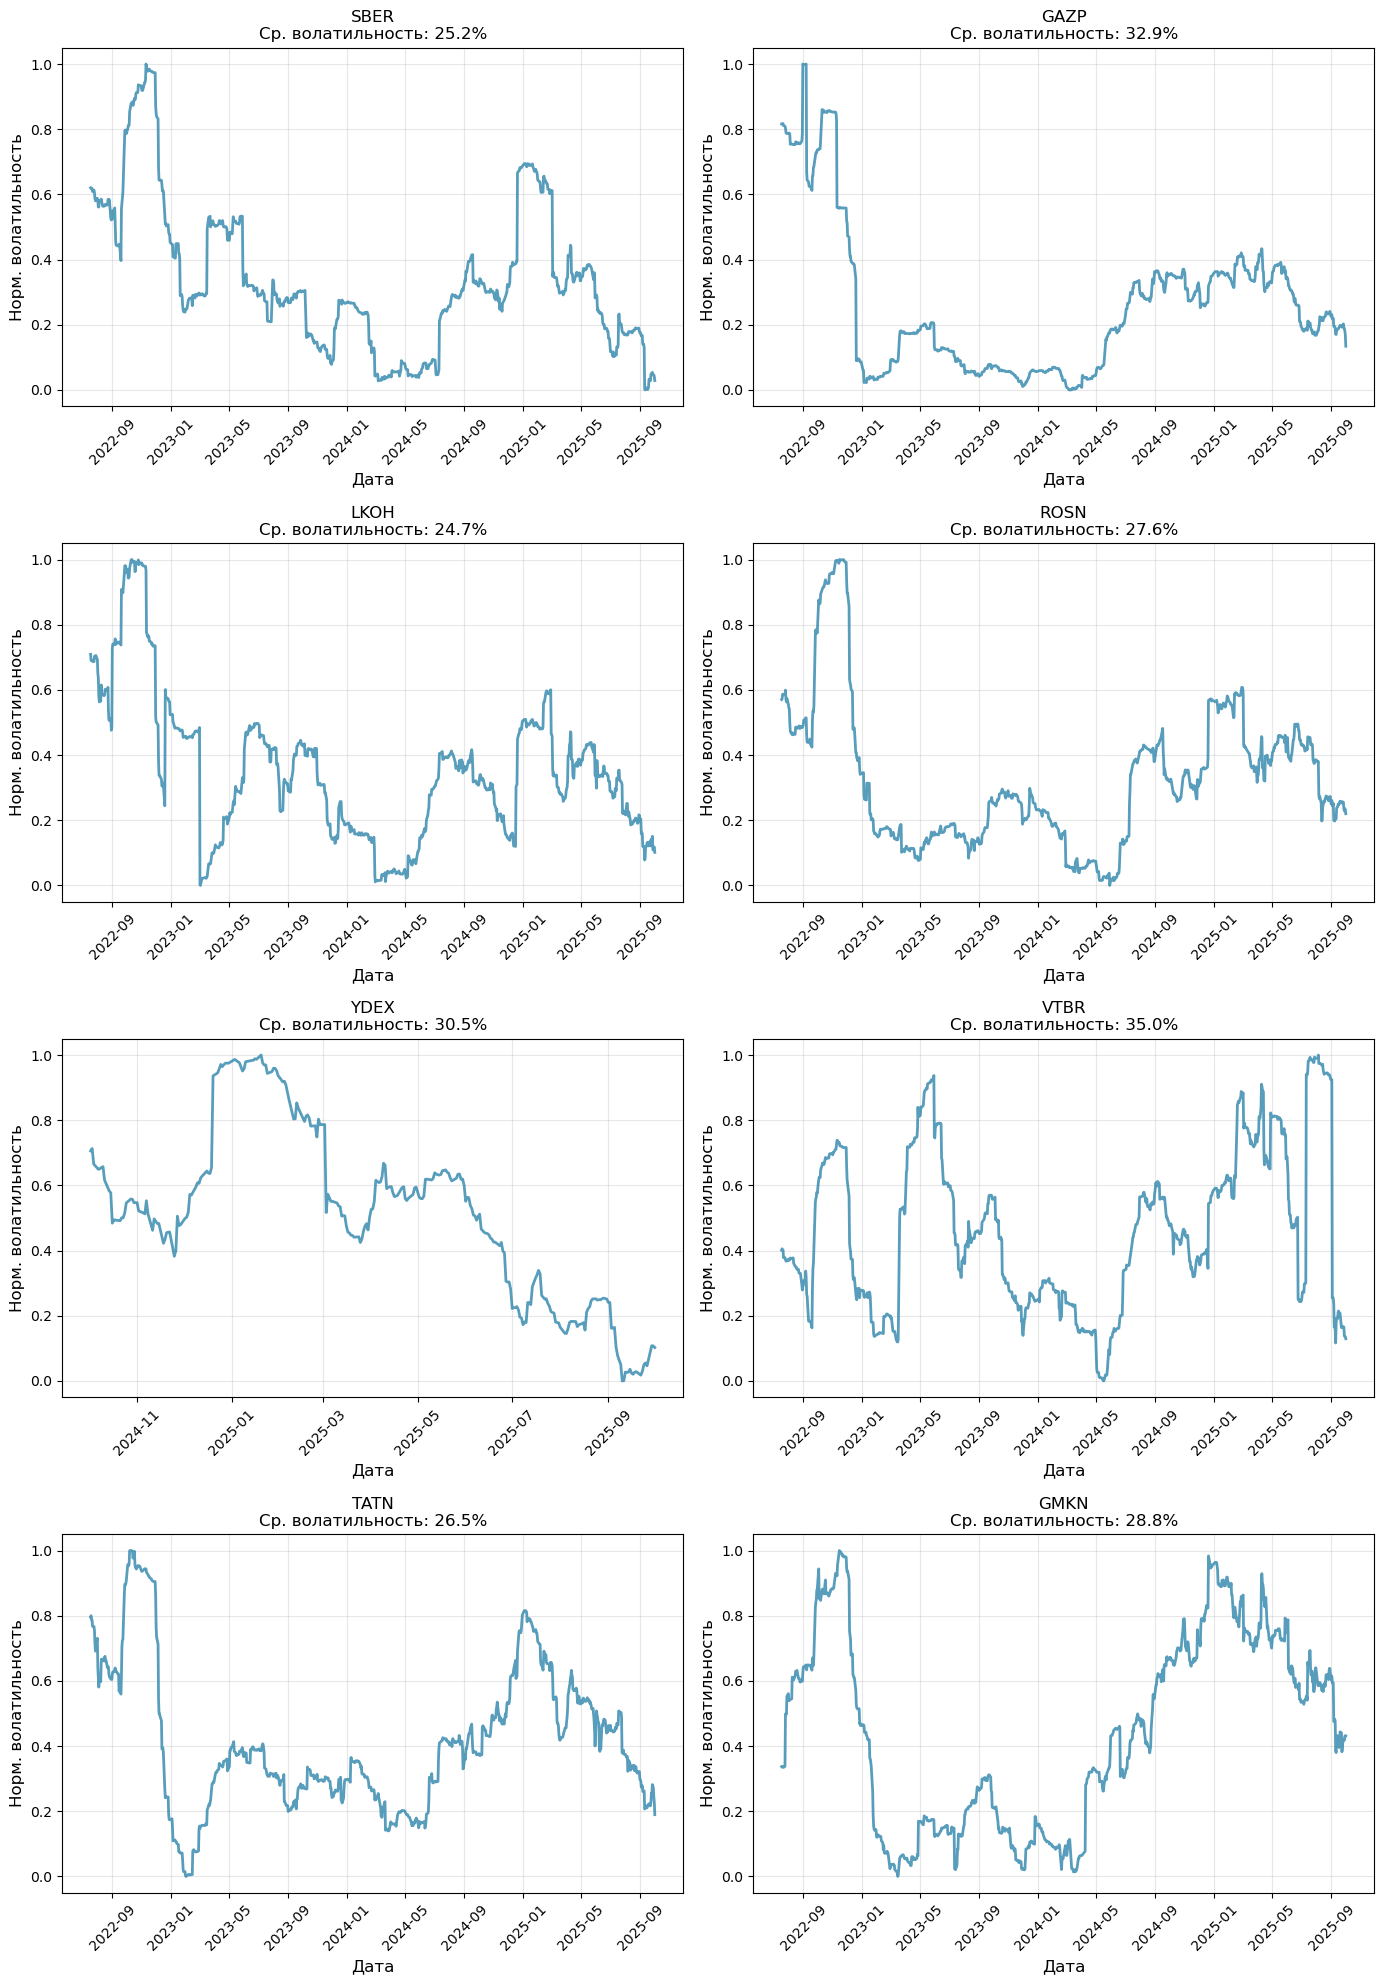

Средняя годовая волатильность по акциям:
----------------------------------------
VTBR: 35.0%
GAZP: 32.9%
YDEX: 30.5%
GMKN: 28.8%
ROSN: 27.6%
TATN: 26.5%
SBER: 25.2%
LKOH: 24.7%

Максимальная: 35.0%
Минимальная: 24.7%
Средняя: 28.9%


In [150]:
plot_normalized_volatility_grid(stock_data_final, window=50)

#### 3.5.3.2 Окно 20 дней

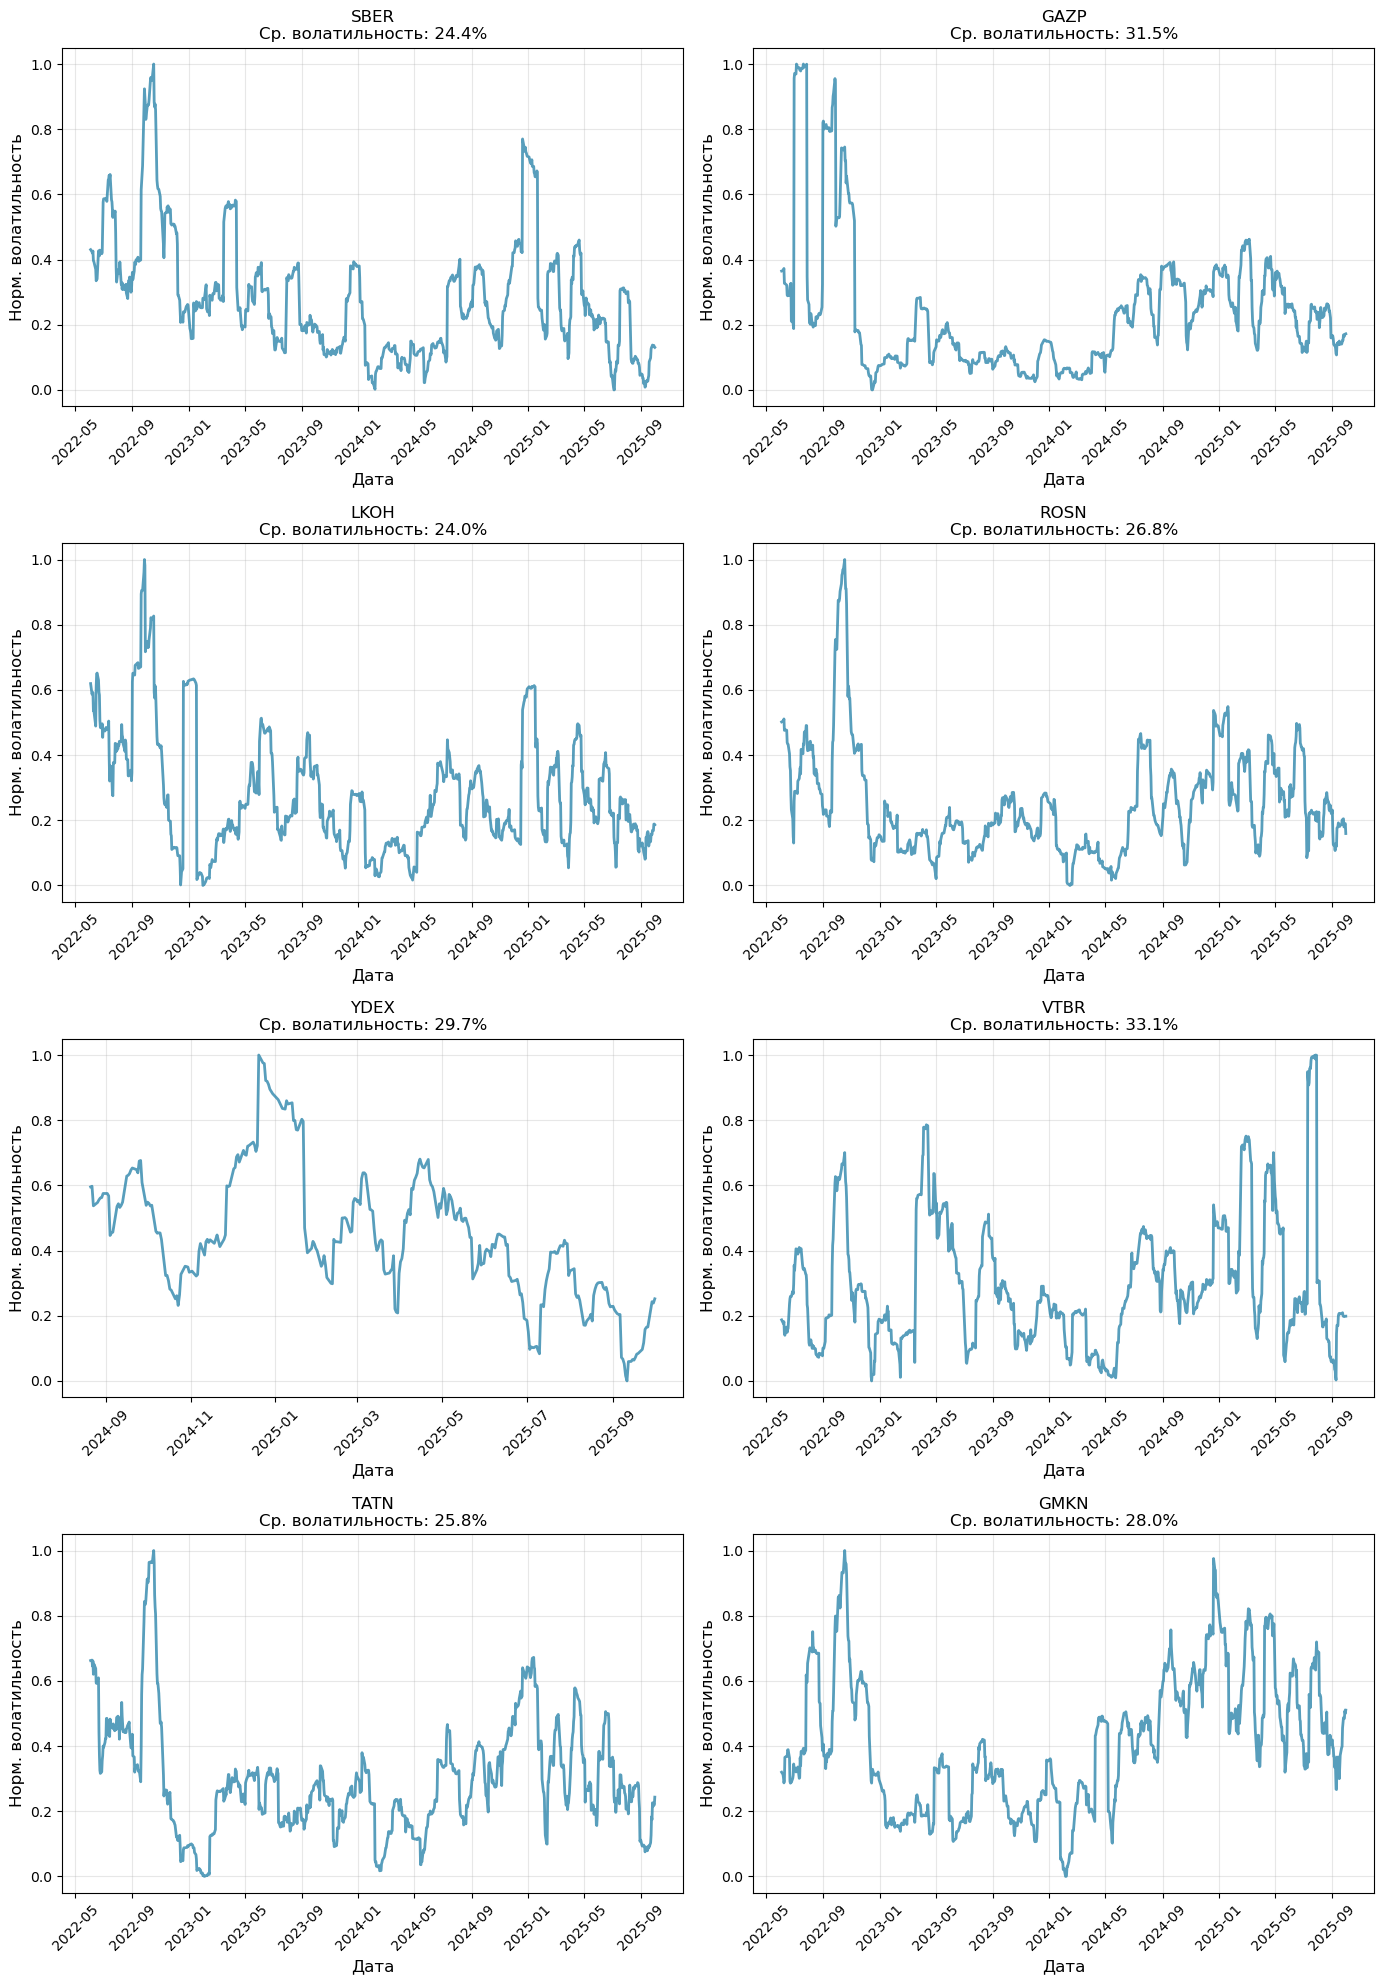

Средняя годовая волатильность по акциям:
----------------------------------------
VTBR: 33.1%
GAZP: 31.5%
YDEX: 29.7%
GMKN: 28.0%
ROSN: 26.8%
TATN: 25.8%
SBER: 24.4%
LKOH: 24.0%

Максимальная: 33.1%
Минимальная: 24.0%
Средняя: 27.9%


In [153]:
plot_normalized_volatility_grid(stock_data_final, window=20)

#### 3.5.3.3 Окно 7 дней

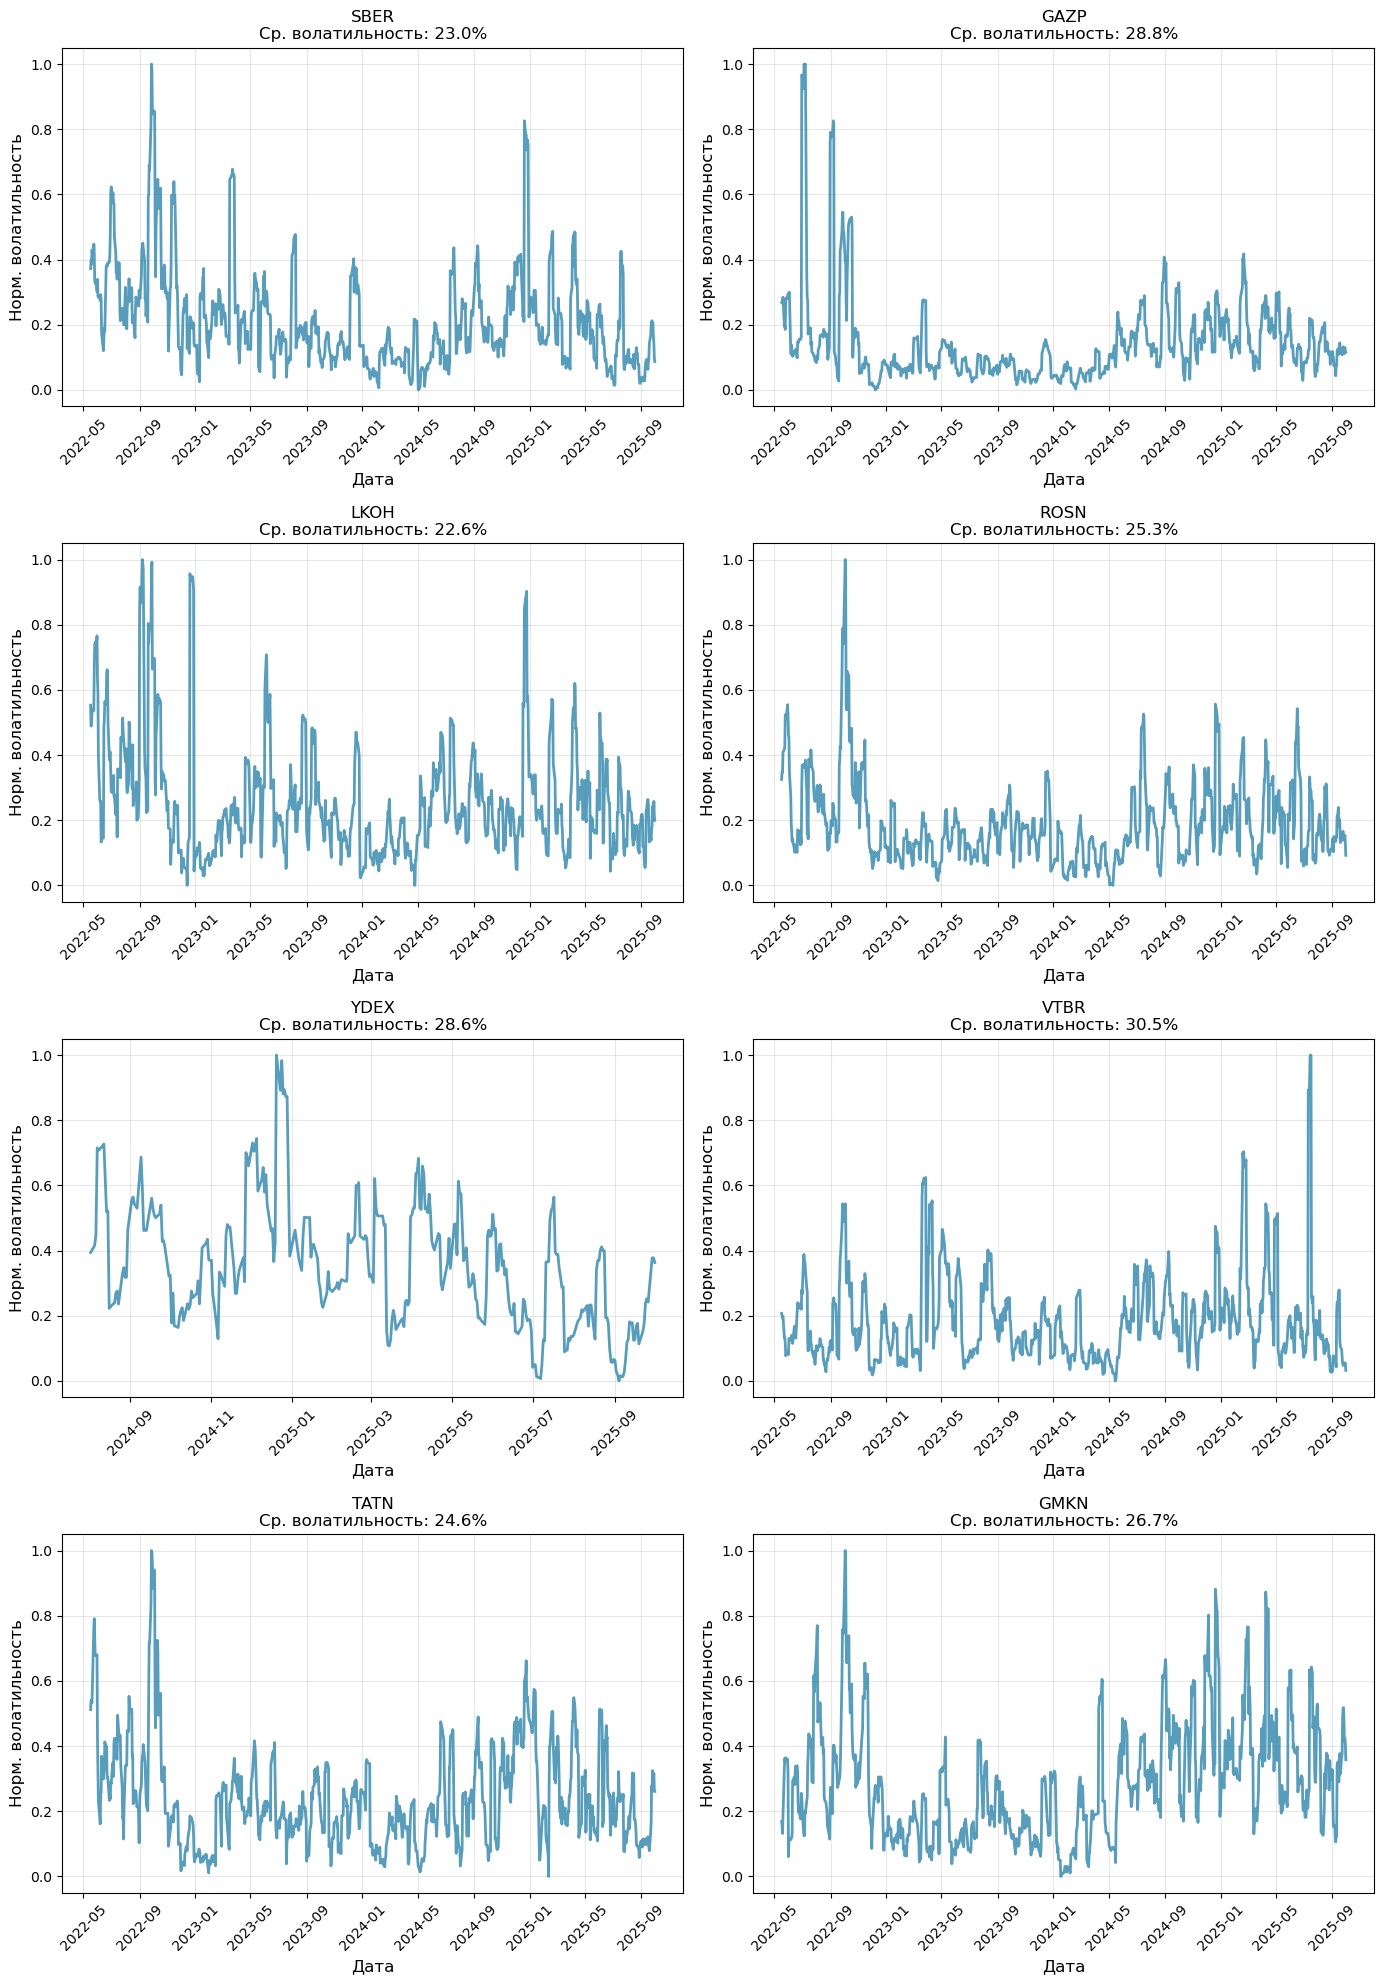

Средняя годовая волатильность по акциям:
----------------------------------------
VTBR: 30.5%
GAZP: 28.8%
YDEX: 28.6%
GMKN: 26.7%
ROSN: 25.3%
TATN: 24.6%
SBER: 23.0%
LKOH: 22.6%

Максимальная: 30.5%
Минимальная: 22.6%
Средняя: 26.3%


In [156]:
plot_normalized_volatility_grid(stock_data_final, window=7)

### Вывод

Относительные значения среднегодовой волотильности акций не меняются от изменения окна, но и не оличаются друг от друга координально </br>
Волатильность снижается при уменьшении окна </br>

## Вывод

Можно также группировать акции по волотильности для использования в различных моделях